Processing 14 galaxies...


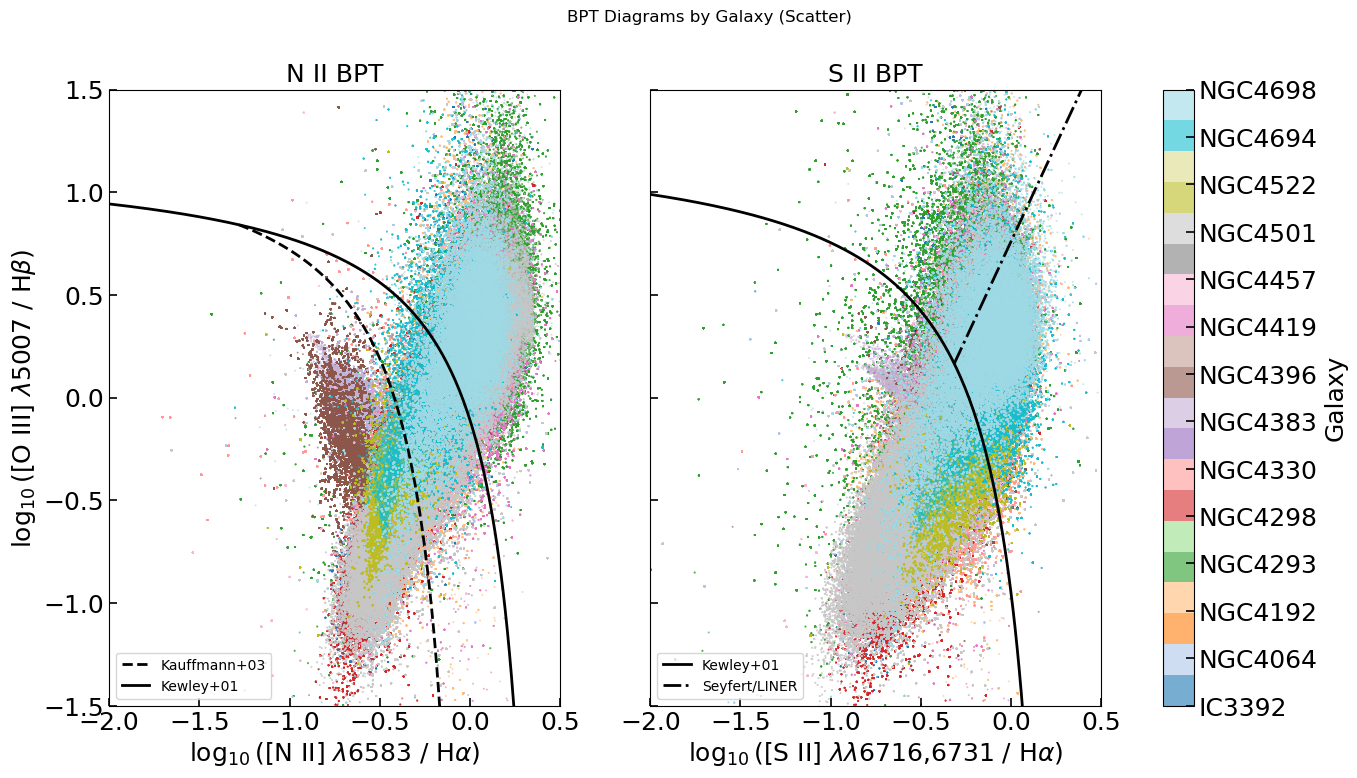

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import gaussian_filter

# Formatting
mpl.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

def kewley01_N2(x): return 0.61/(x-0.47) + 1.19
def kauff03_N2(x): return 0.61/(x-0.05) + 1.30
def kewley01_S2(x): return 0.72/(x-0.32) + 1.30
def kewley06_Sy_LIN(x): return 1.89*x + 0.76

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

all_logN2 = []
all_logS2 = []
all_logO3 = []
all_gal_idx = []

print(f"Processing {len(galaxies)} galaxies...")

for i, gal in enumerate(galaxies):
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if gas_file.exists():
        with fits.open(gas_file) as h:
            HB_corr = h['HB4861_FLUX_CORR'].data
            HA_corr = h['HA6562_FLUX_CORR'].data
            OIII_corr = h['OIII5006_FLUX_CORR'].data
            NII_corr = h['NII6583_FLUX_CORR'].data
            SII6716_corr = h['SII6716_FLUX_CORR'].data
            SII6730_corr = h['SII6730_FLUX_CORR'].data
            
            # valid mask
            flux_mask = (
                np.isfinite(HB_corr) & (HB_corr > 0) &
                np.isfinite(HA_corr) & (HA_corr > 0) &
                np.isfinite(OIII_corr) & (OIII_corr > 0) &
                np.isfinite(NII_corr) & (NII_corr > 0) &
                np.isfinite(SII6716_corr) & (SII6716_corr > 0) &
                np.isfinite(SII6730_corr) & (SII6730_corr > 0)
            )

            # try to use LOGSFR_SURFACE_DENSITY like the other notebook if it exists
            # Otherwise fallback to just flux mask.
            sfr_mask = np.ones_like(flux_mask)
            if 'LOGSFR_SURFACE_DENSITY' in h:
                sfr_mask = np.isfinite(h['LOGSFR_SURFACE_DENSITY'].data)

            valid_mask = flux_mask & sfr_mask
            
            logN2 = np.log10(NII_corr[valid_mask] / HA_corr[valid_mask])
            logS2 = np.log10((SII6716_corr[valid_mask] + SII6730_corr[valid_mask]) / HA_corr[valid_mask])
            logO3 = np.log10(OIII_corr[valid_mask] / HB_corr[valid_mask])
            
            valid_ratios = np.isfinite(logN2) & np.isfinite(logS2) & np.isfinite(logO3)
            
            all_logN2.extend(logN2[valid_ratios])
            all_logS2.extend(logS2[valid_ratios])
            all_logO3.extend(logO3[valid_ratios])
            all_gal_idx.extend(np.full(np.sum(valid_ratios), i))

all_logN2 = np.array(all_logN2)
all_logS2 = np.array(all_logS2)
all_logO3 = np.array(all_logO3)
all_gal_idx = np.array(all_gal_idx)

cmap = plt.get_cmap('tab20')
colors = [cmap(i/len(galaxies)) for i in range(len(galaxies))]

# Subplots 1: Scatter for all galaxies
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Scatter N2
sc0 = axes[0].scatter(all_logN2, all_logO3, c=all_gal_idx, cmap=cmap, s=2, alpha=0.6, edgecolors='none')
axes[0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0].set_xlim(-2.0, 0.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0].legend(loc='lower left', fontsize=10)
axes[0].set_title("N II BPT")

# Scatter S2
sc1 = axes[1].scatter(all_logS2, all_logO3, c=all_gal_idx, cmap=cmap, s=2, alpha=0.6, edgecolors='none')
axes[1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1].set_xlim(-2.0, 0.5)
axes[1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].set_title("S II BPT")

cbar = plt.colorbar(sc1, ax=axes, ticks=np.arange(len(galaxies)))
cbar.ax.set_yticklabels(galaxies)
cbar.set_label('Galaxy')

plt.suptitle("BPT Diagrams by Galaxy (Scatter)")
plt.show()

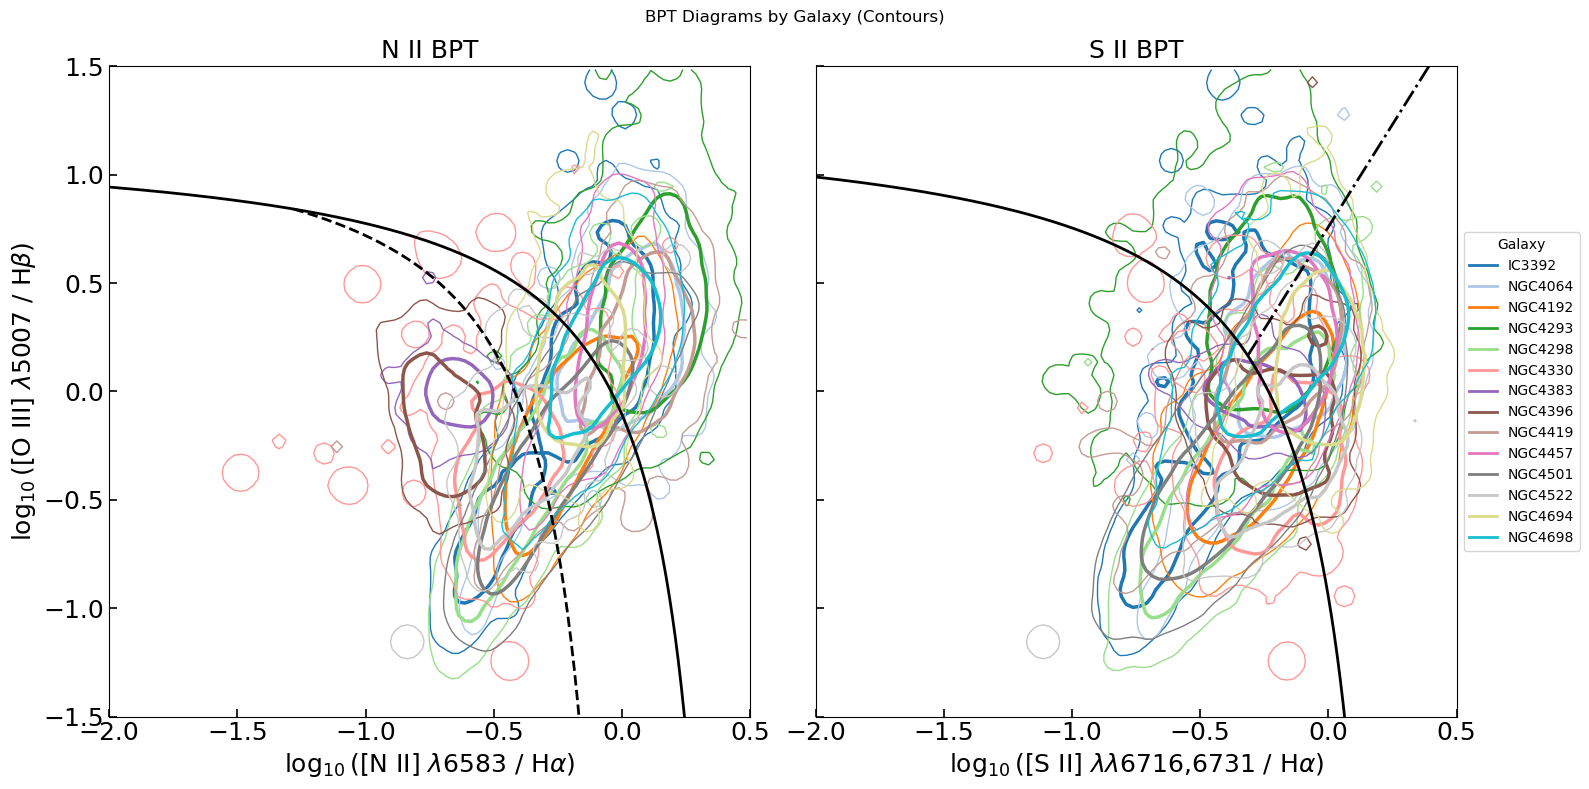

In [2]:
def plot_contours(ax, x, y, color, label=None, levels=[0.68, 0.95], bins=100, smooth=1.5):
    if len(x) < 10:
        return
    H, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[-2.0, 0.5], [-1.5, 1.5]])
    H = H.T
    if smooth is not None:
        H = gaussian_filter(H, smooth)
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    H_flat = H.flatten()
    inds = np.argsort(H_flat)[::-1]
    H_sorted = H_flat[inds]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum /= H_cumsum[-1]
    
    contour_levels = []
    for level in sorted(levels, reverse=True):
        idx = np.searchsorted(H_cumsum, level)
        if idx < len(H_sorted):
            contour_levels.append(H_sorted[idx])
            
    contour_levels = sorted(list(set(contour_levels)))
    if len(contour_levels) > 0:
        linewidths = [1, 2.5] if len(contour_levels) == 2 else [1.5]*len(contour_levels)
        ax.contour(x_centers, y_centers, H, levels=contour_levels, colors=[color], linewidths=linewidths)
        ax.plot([], [], color=color, label=label, lw=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for i, gal in enumerate(galaxies):
    mask = (all_gal_idx == i)
    # NII
    plot_contours(axes[0], all_logN2[mask], all_logO3[mask], colors[i], label=gal, bins=100, smooth=1.5)
    # SII
    plot_contours(axes[1], all_logS2[mask], all_logO3[mask], colors[i], label=gal, bins=100, smooth=1.5)

# NII
axes[0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0].set_xlim(-2.0, 0.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0].set_title("N II BPT")

# SII
axes[1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1].set_xlim(-2.0, 0.5)
axes[1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1].set_title("S II BPT")

# Just plot dummy legend for colors on right side
handles = [plt.Line2D([0],[0], color=c, lw=2, label=g) for c, g in zip(colors, galaxies)]
axes[1].legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title="Galaxy")

plt.suptitle("BPT Diagrams by Galaxy (Contours)")
plt.tight_layout()
plt.show()

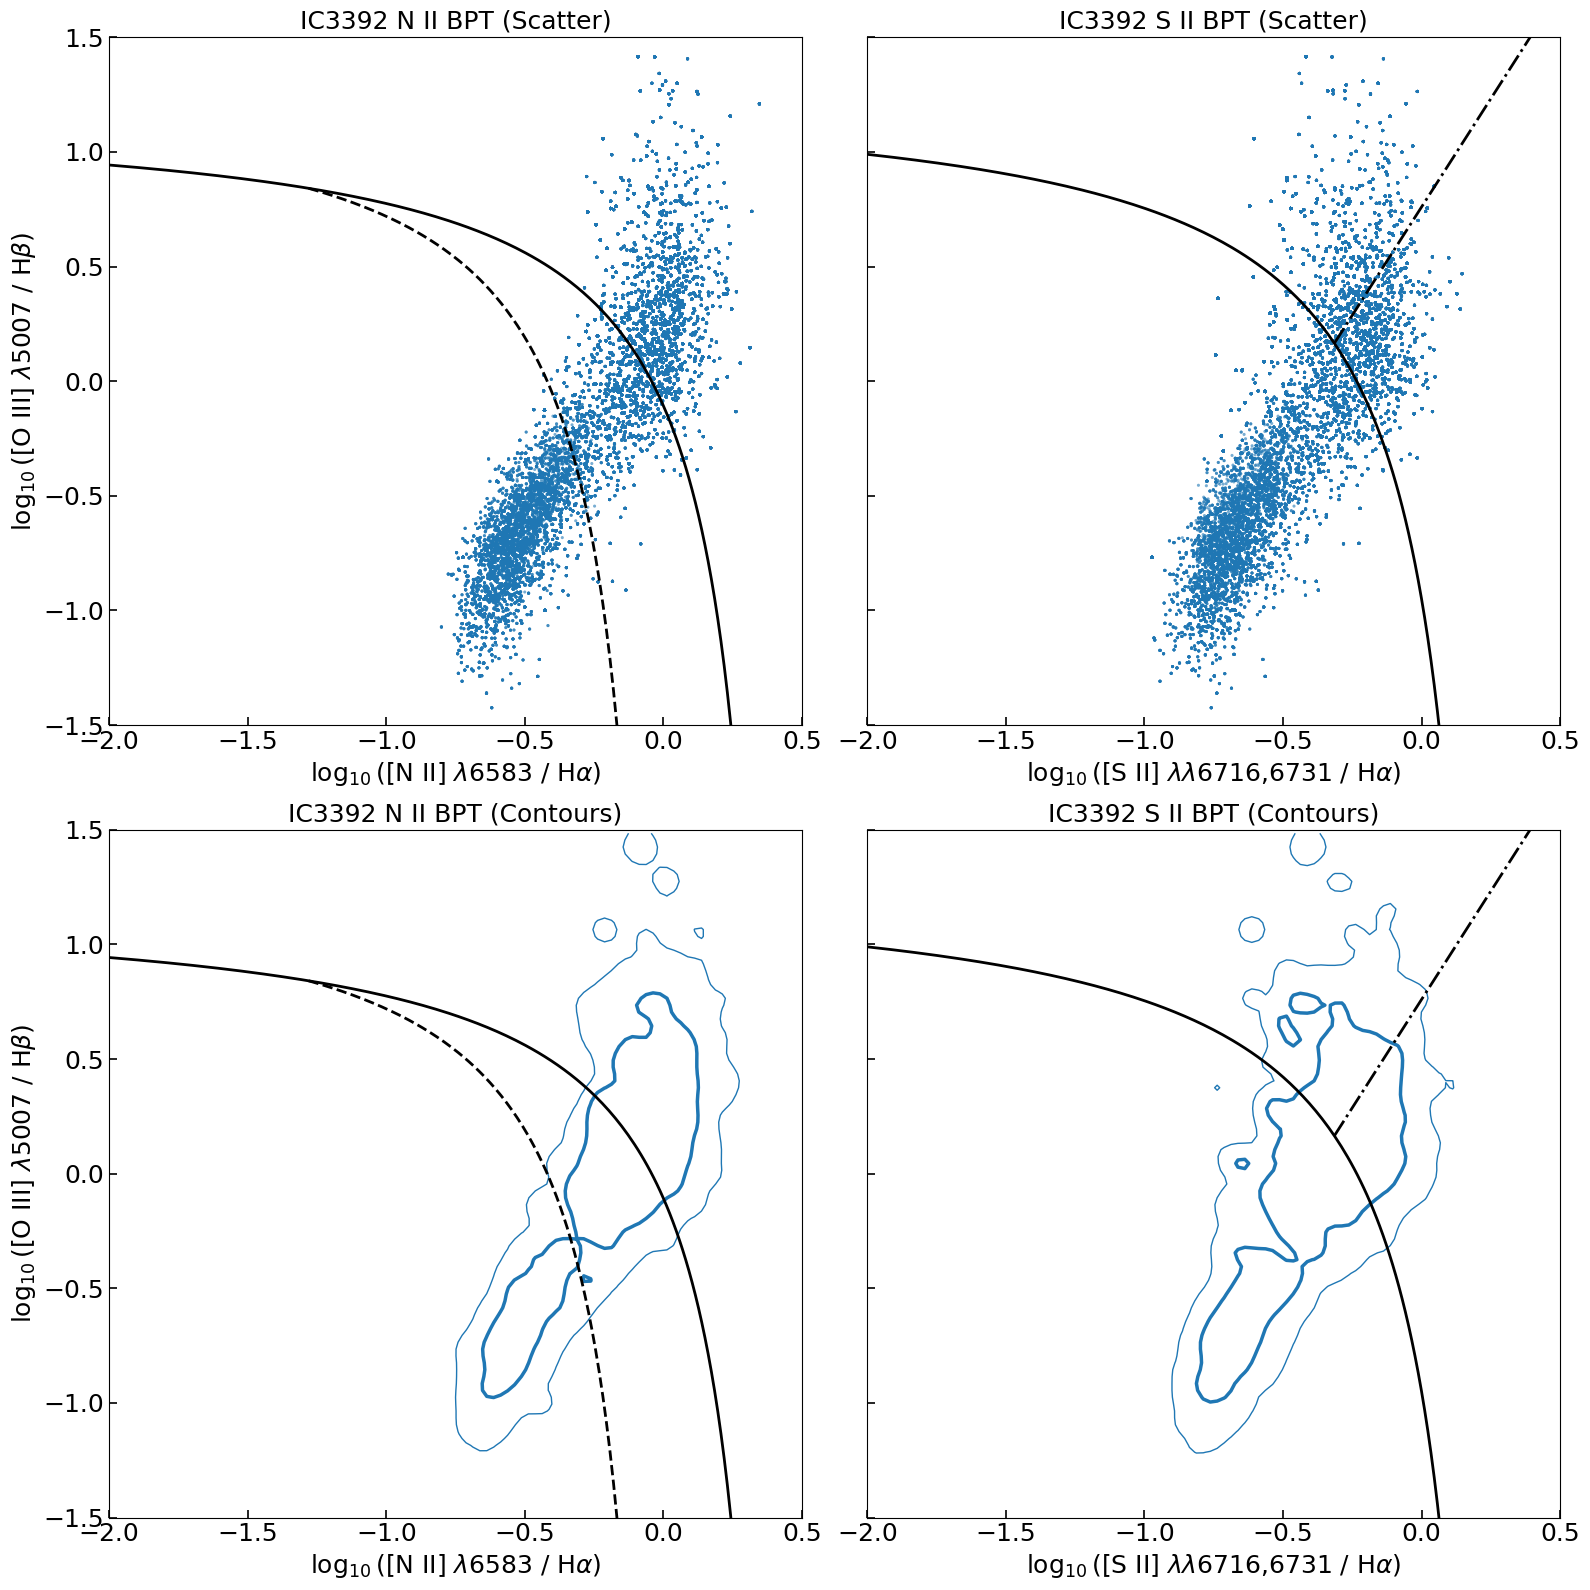

In [3]:
gal = "IC3392"
i = 0

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

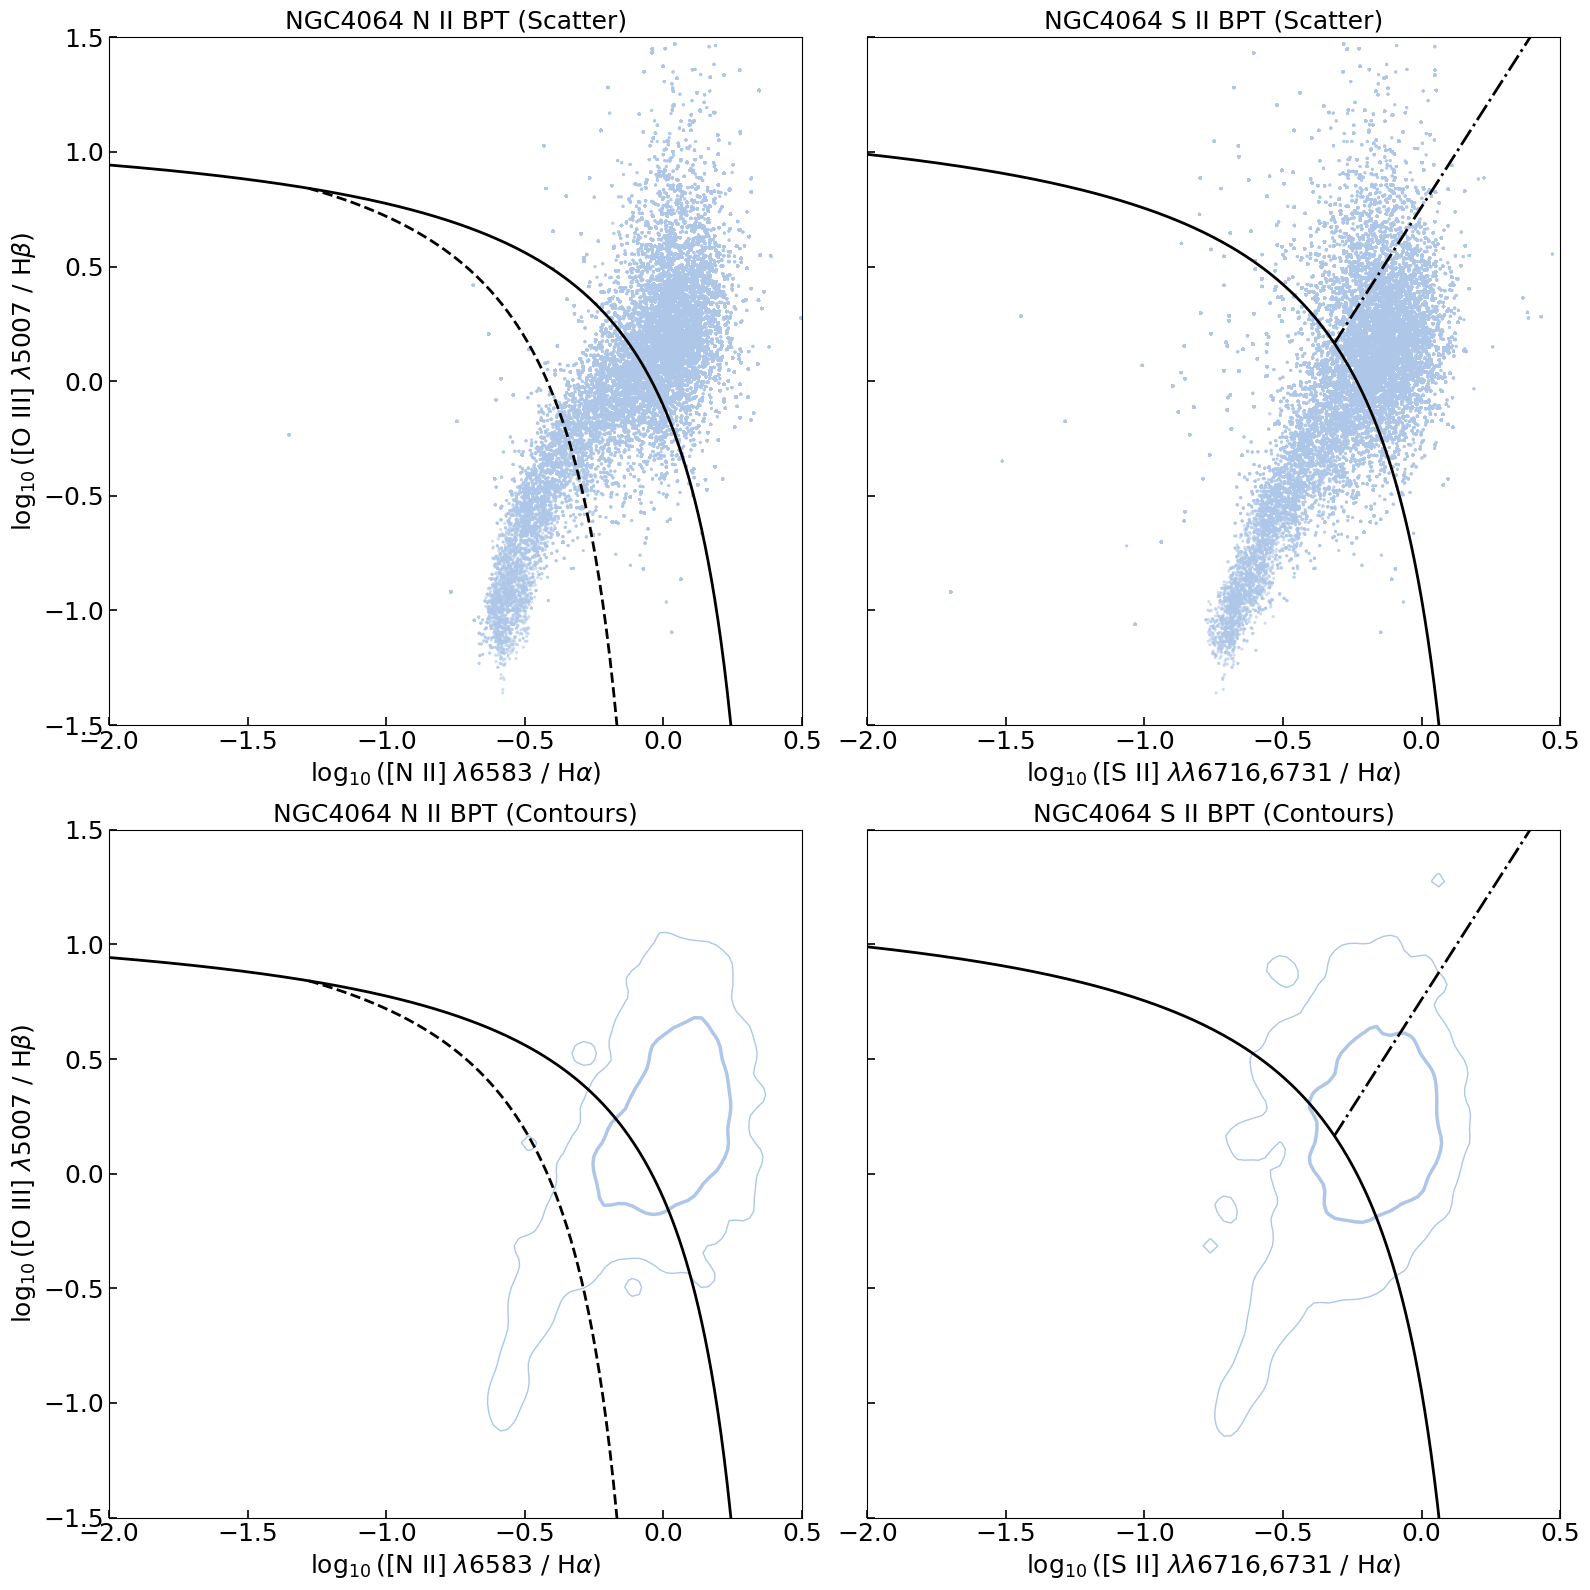

In [4]:
gal = "NGC4064"
i = 1

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

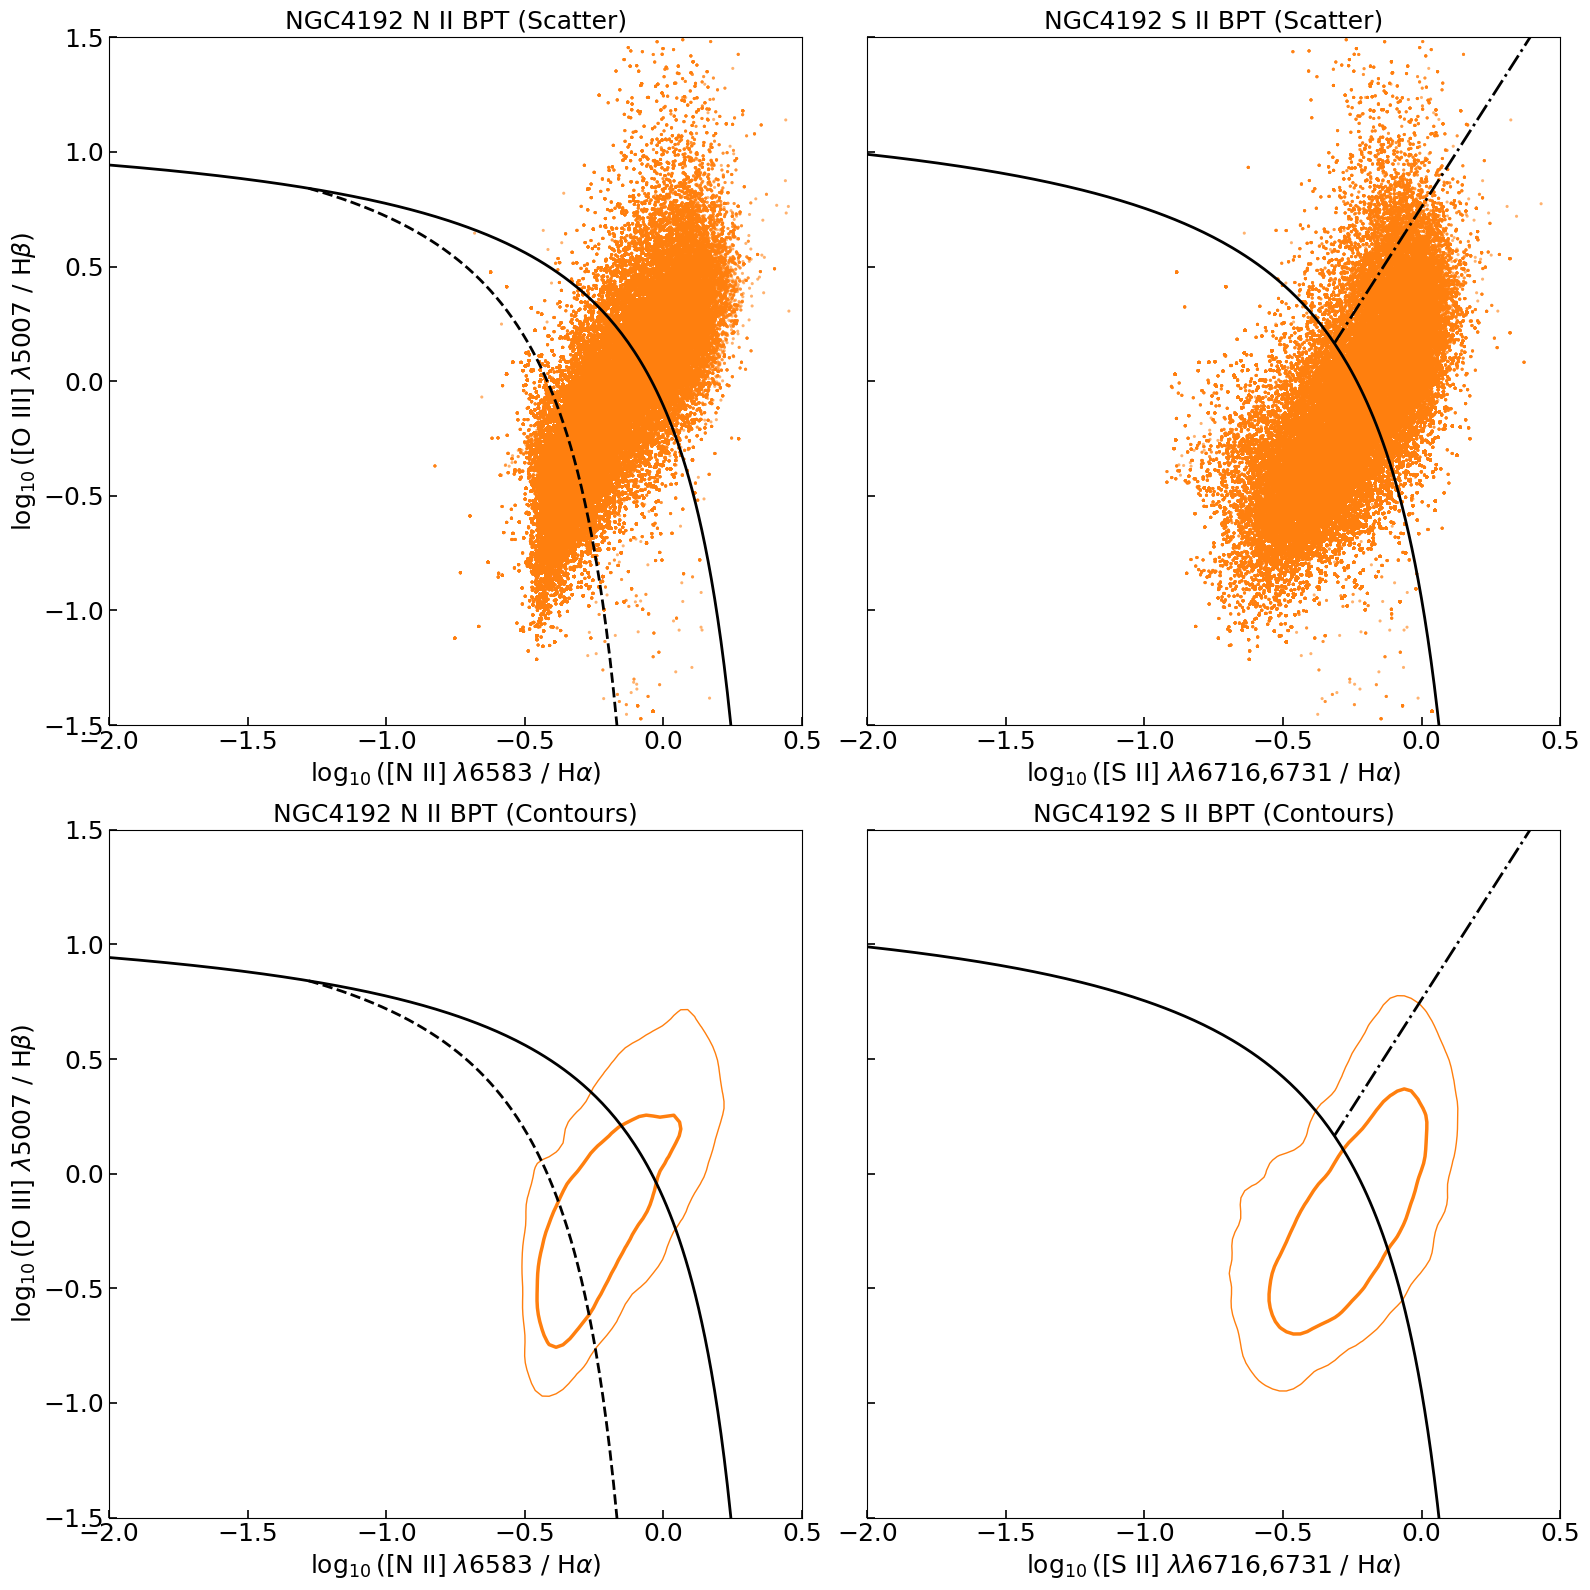

In [5]:
gal = "NGC4192"
i = 2

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

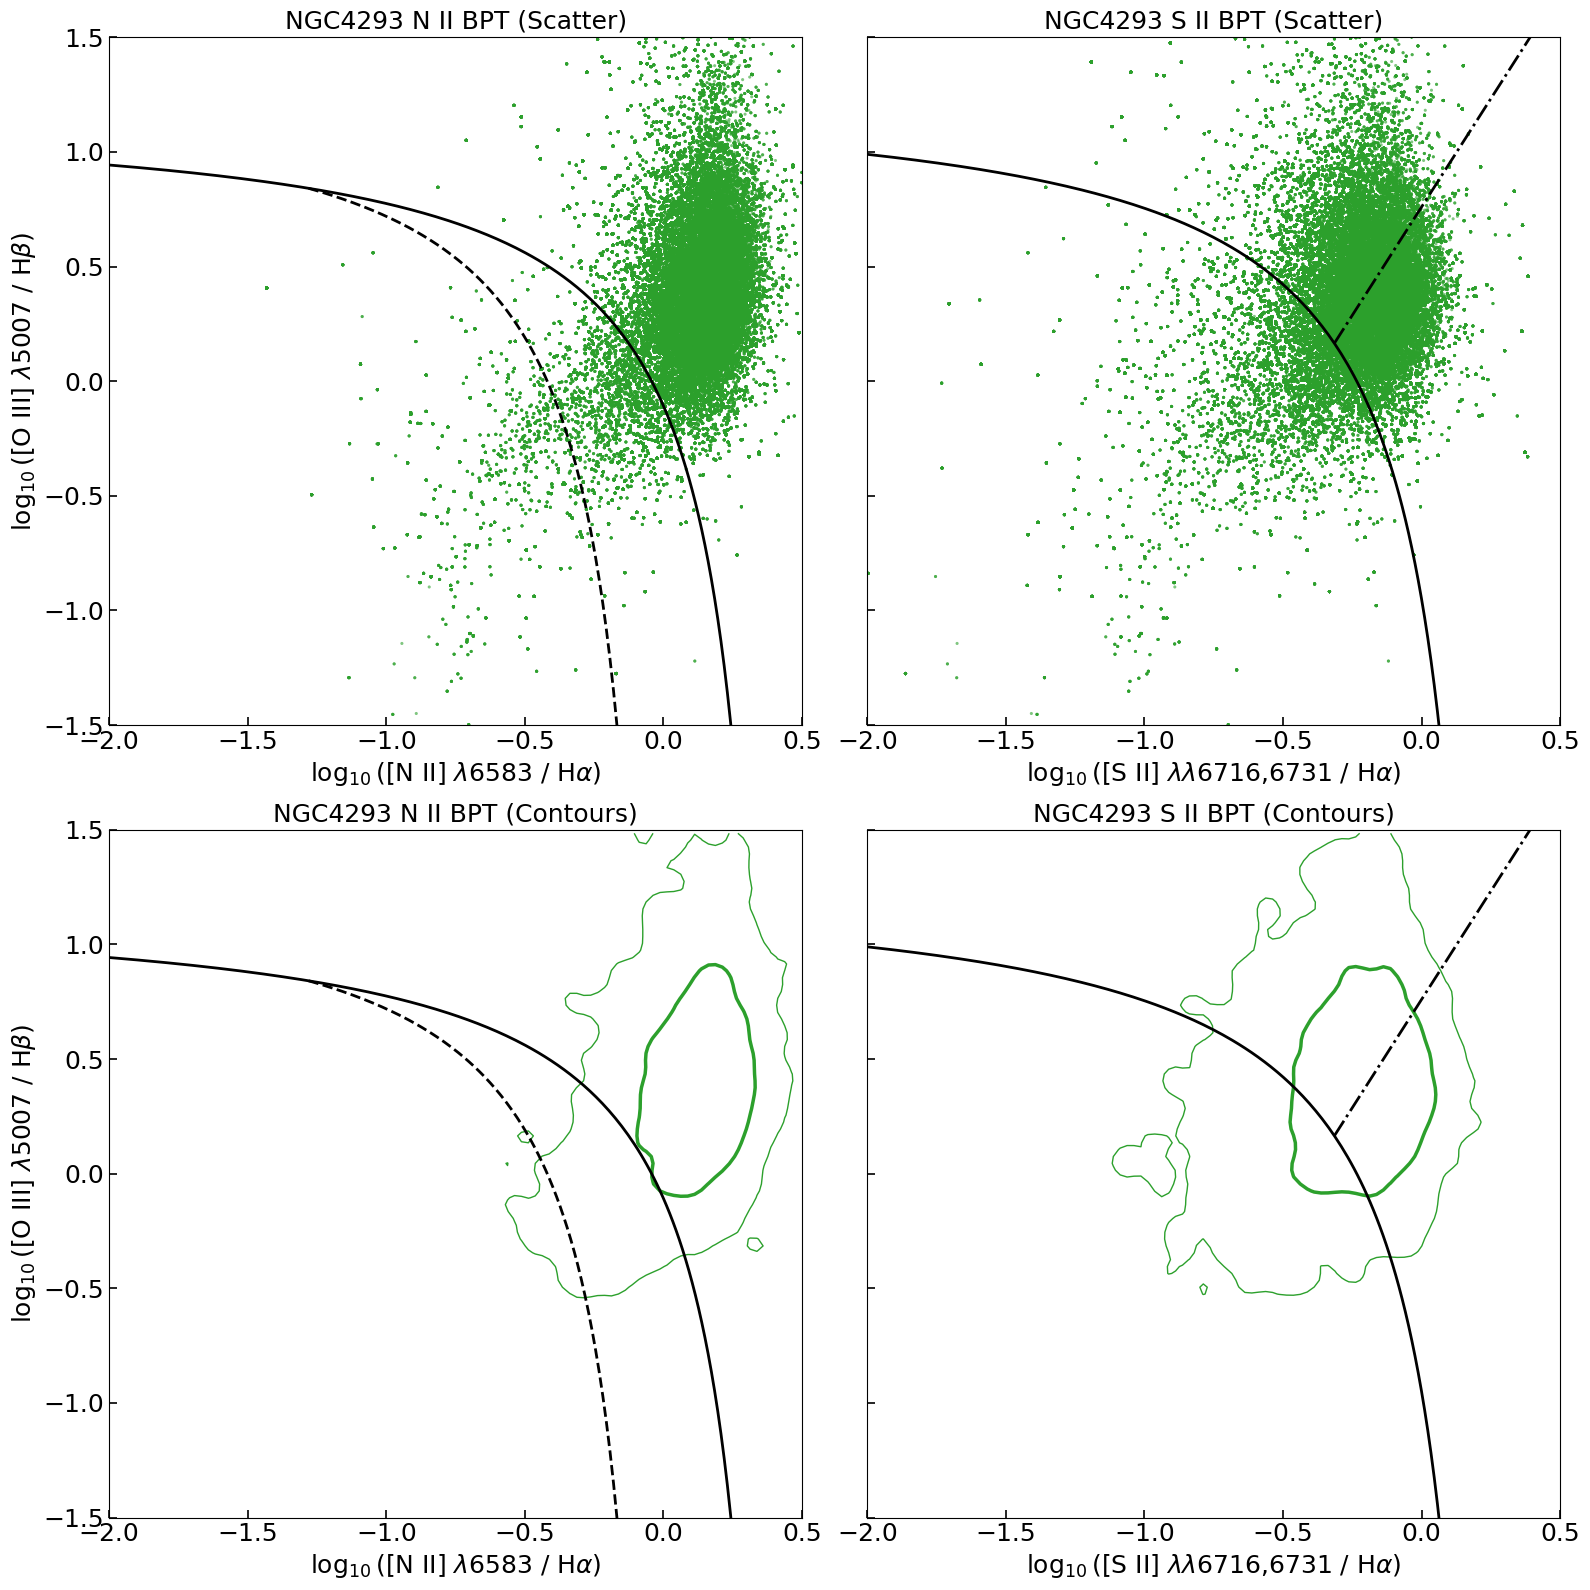

In [6]:
gal = "NGC4293"
i = 3

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

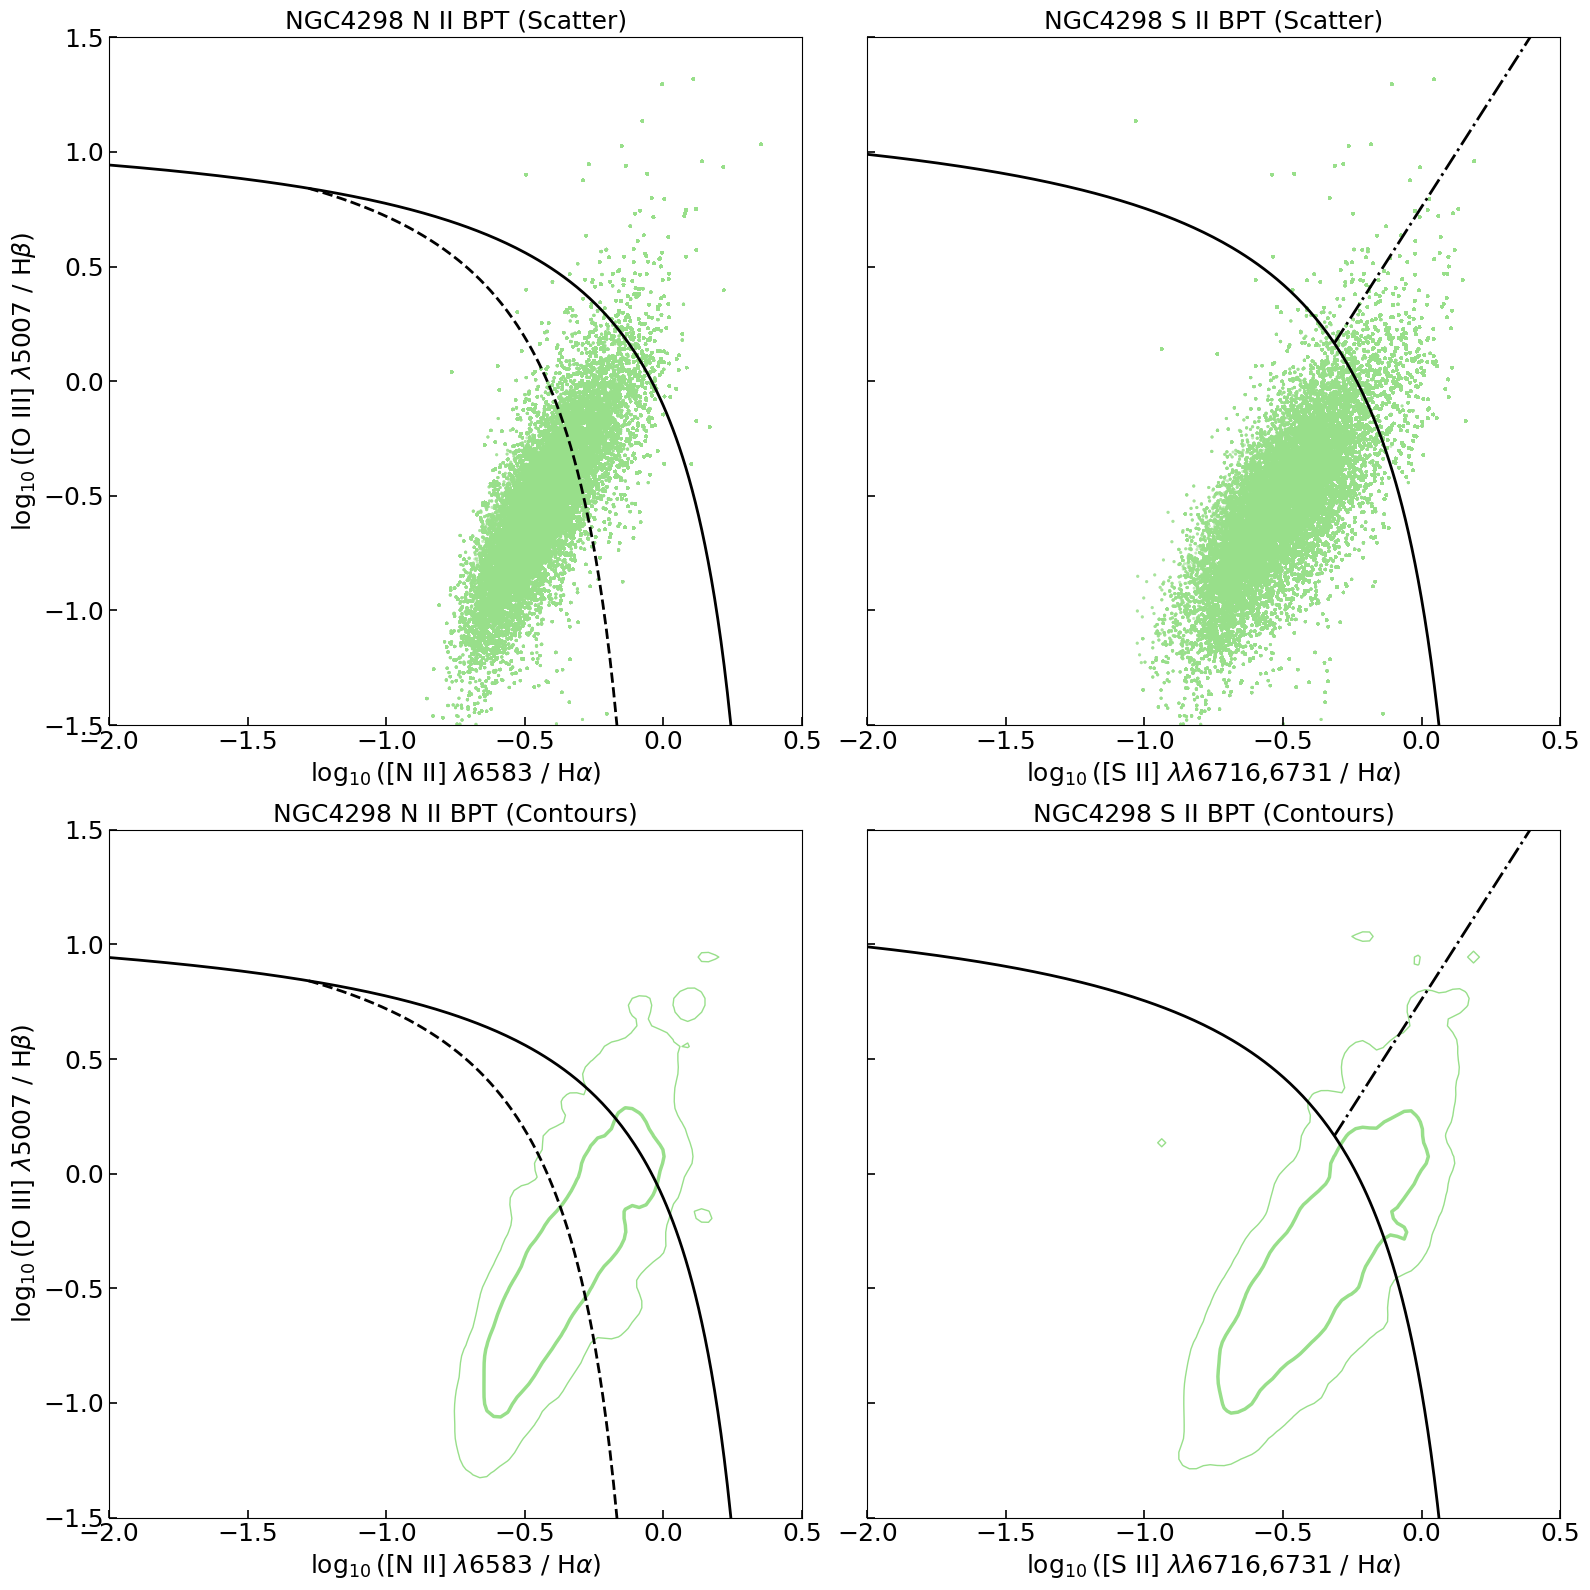

In [7]:
gal = "NGC4298"
i = 4

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

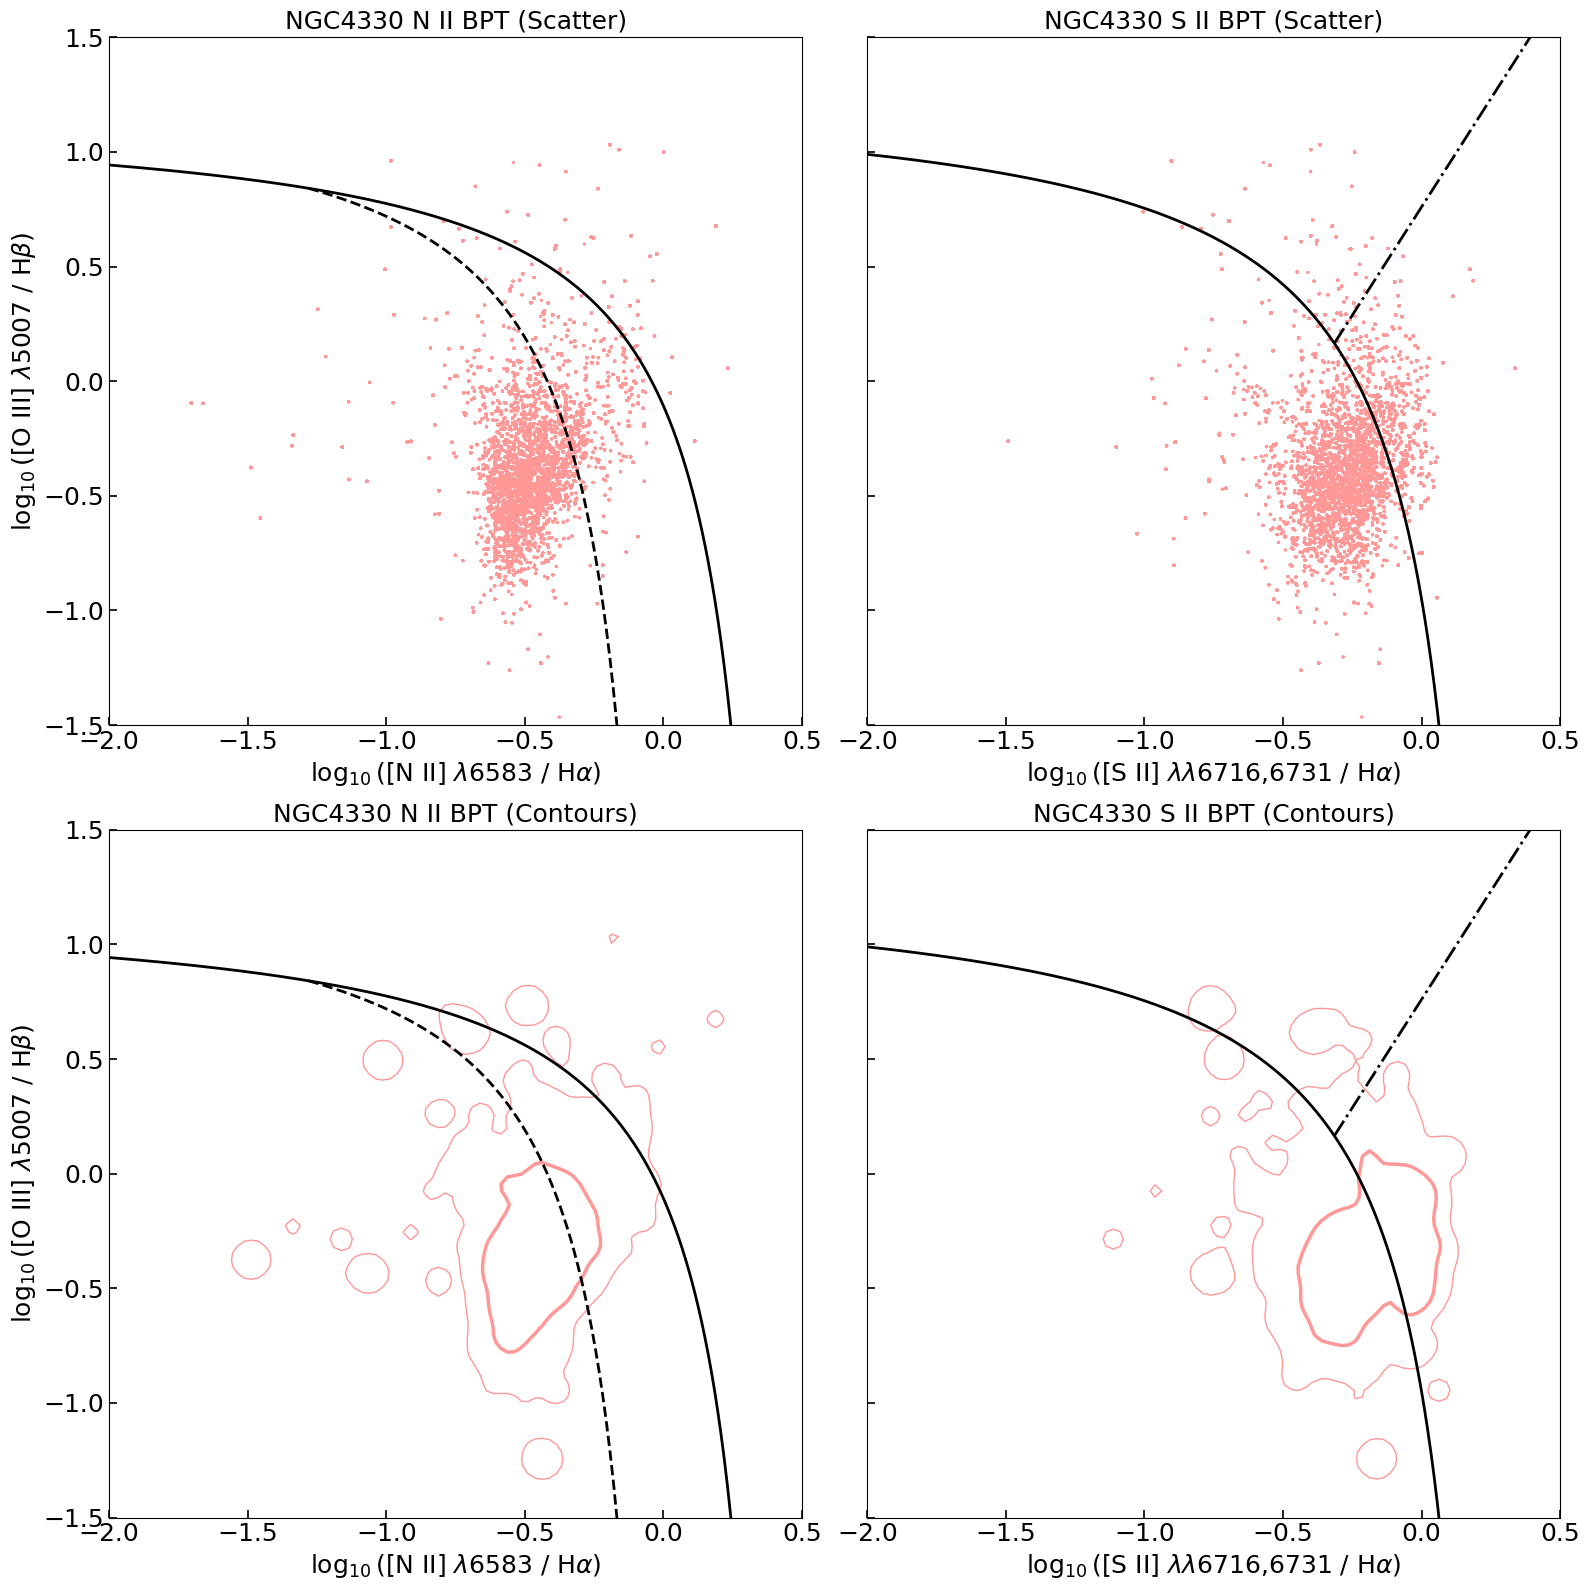

In [8]:
gal = "NGC4330"
i = 5

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

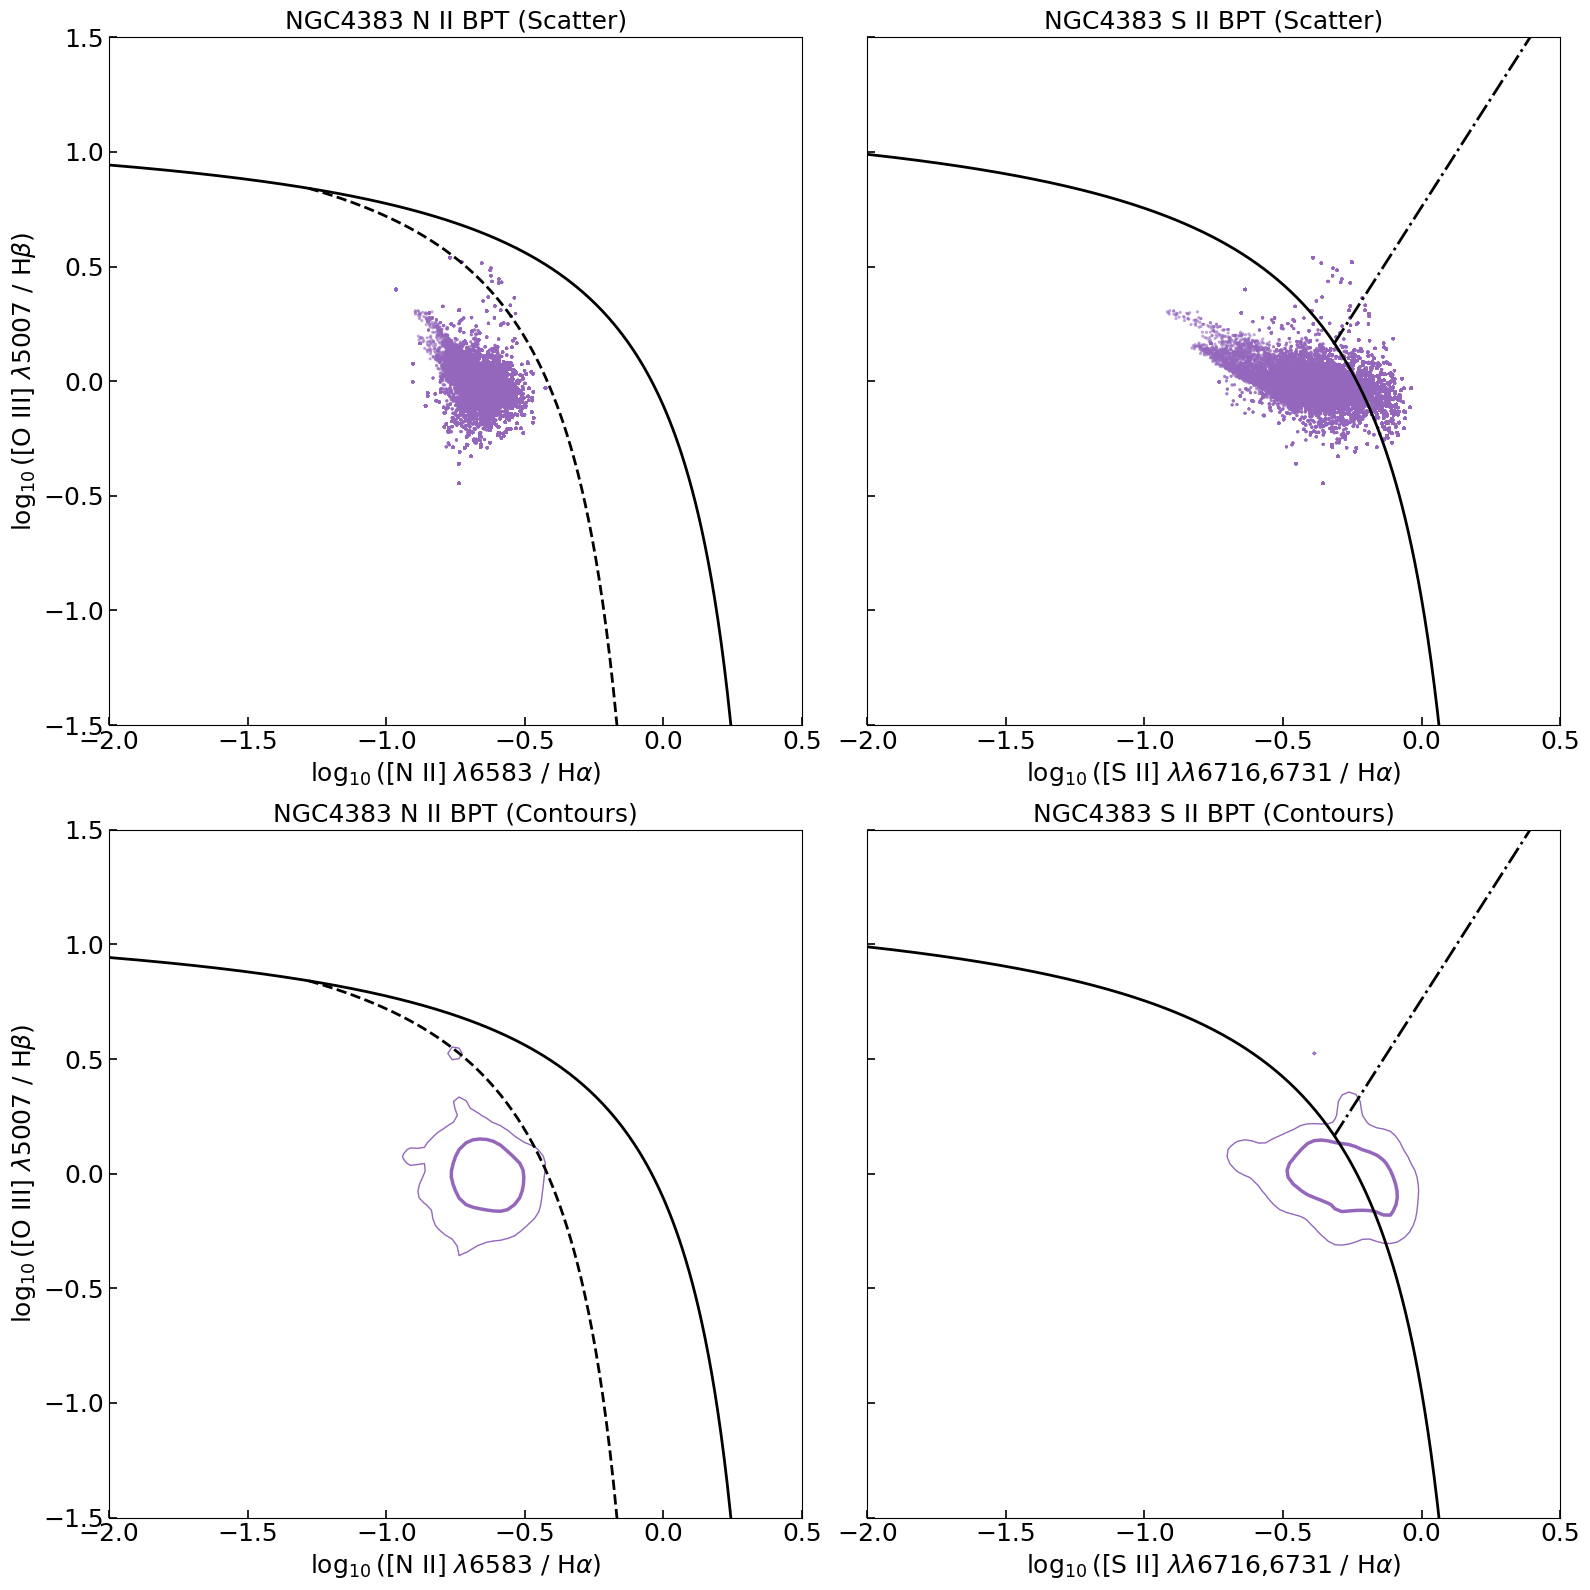

In [9]:
gal = "NGC4383"
i = 6

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

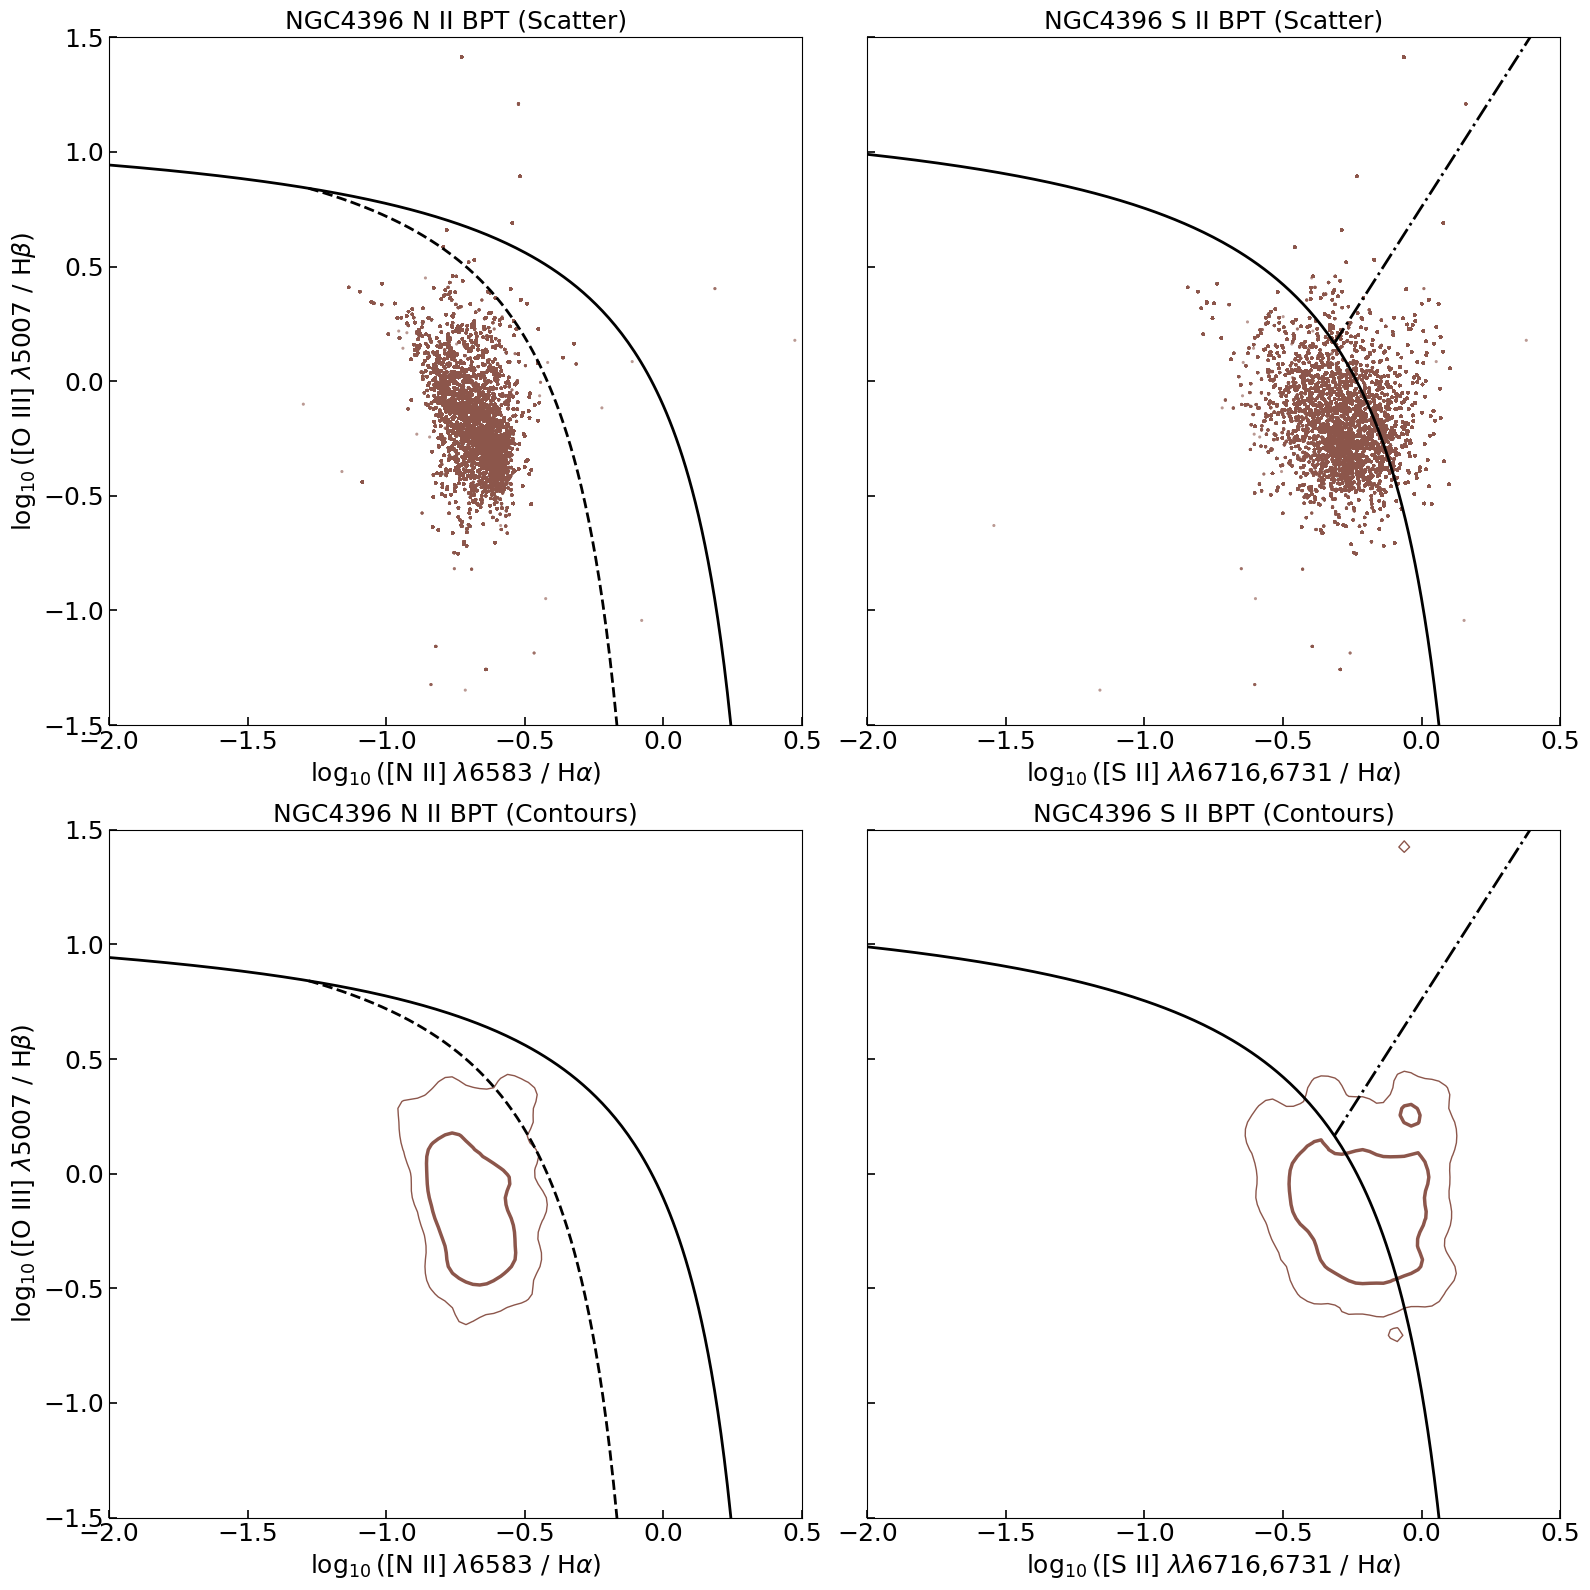

In [10]:
gal = "NGC4396"
i = 7

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

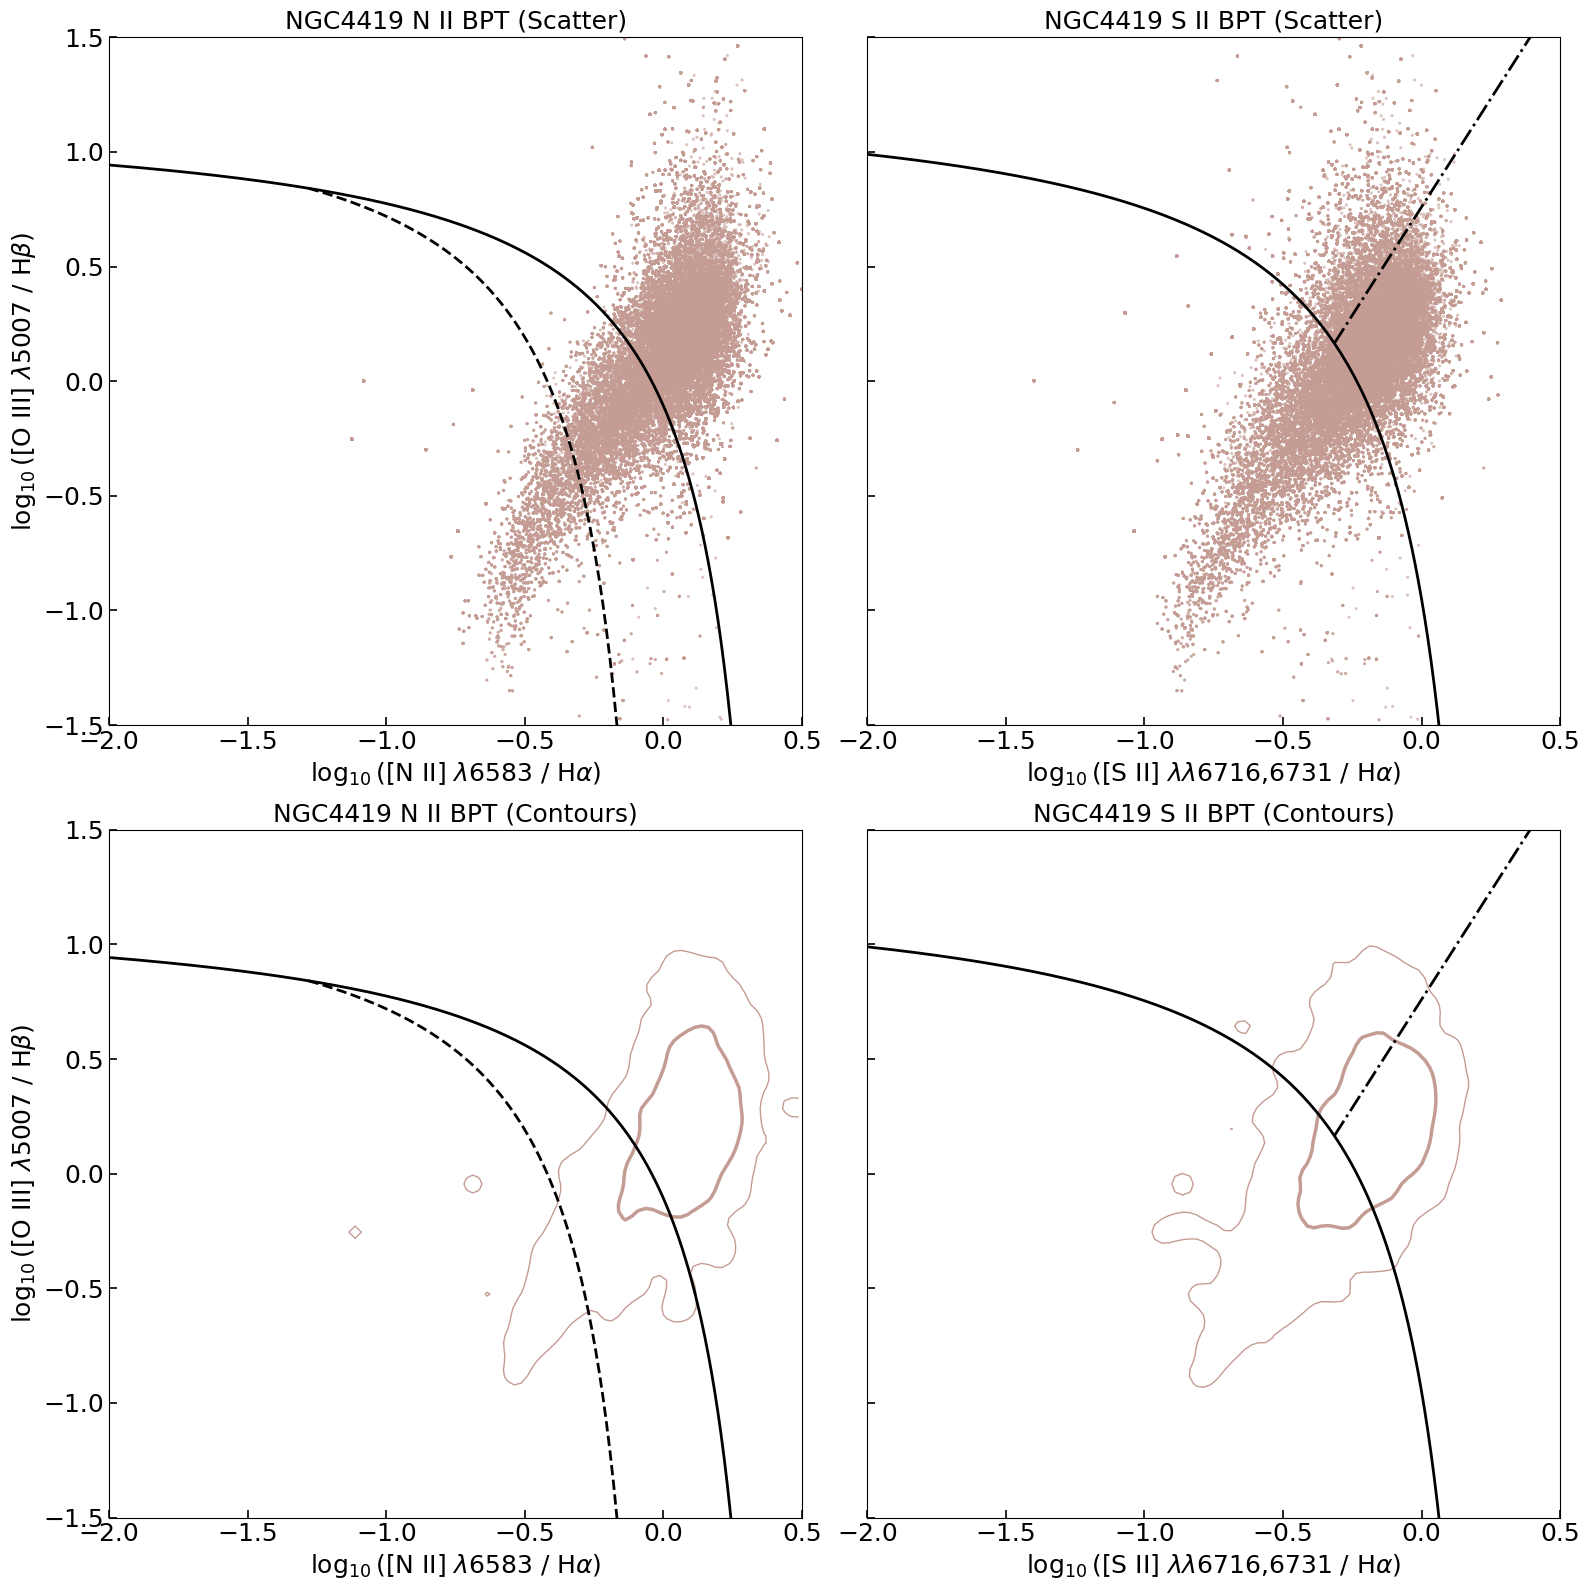

In [11]:
gal = "NGC4419"
i = 8

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

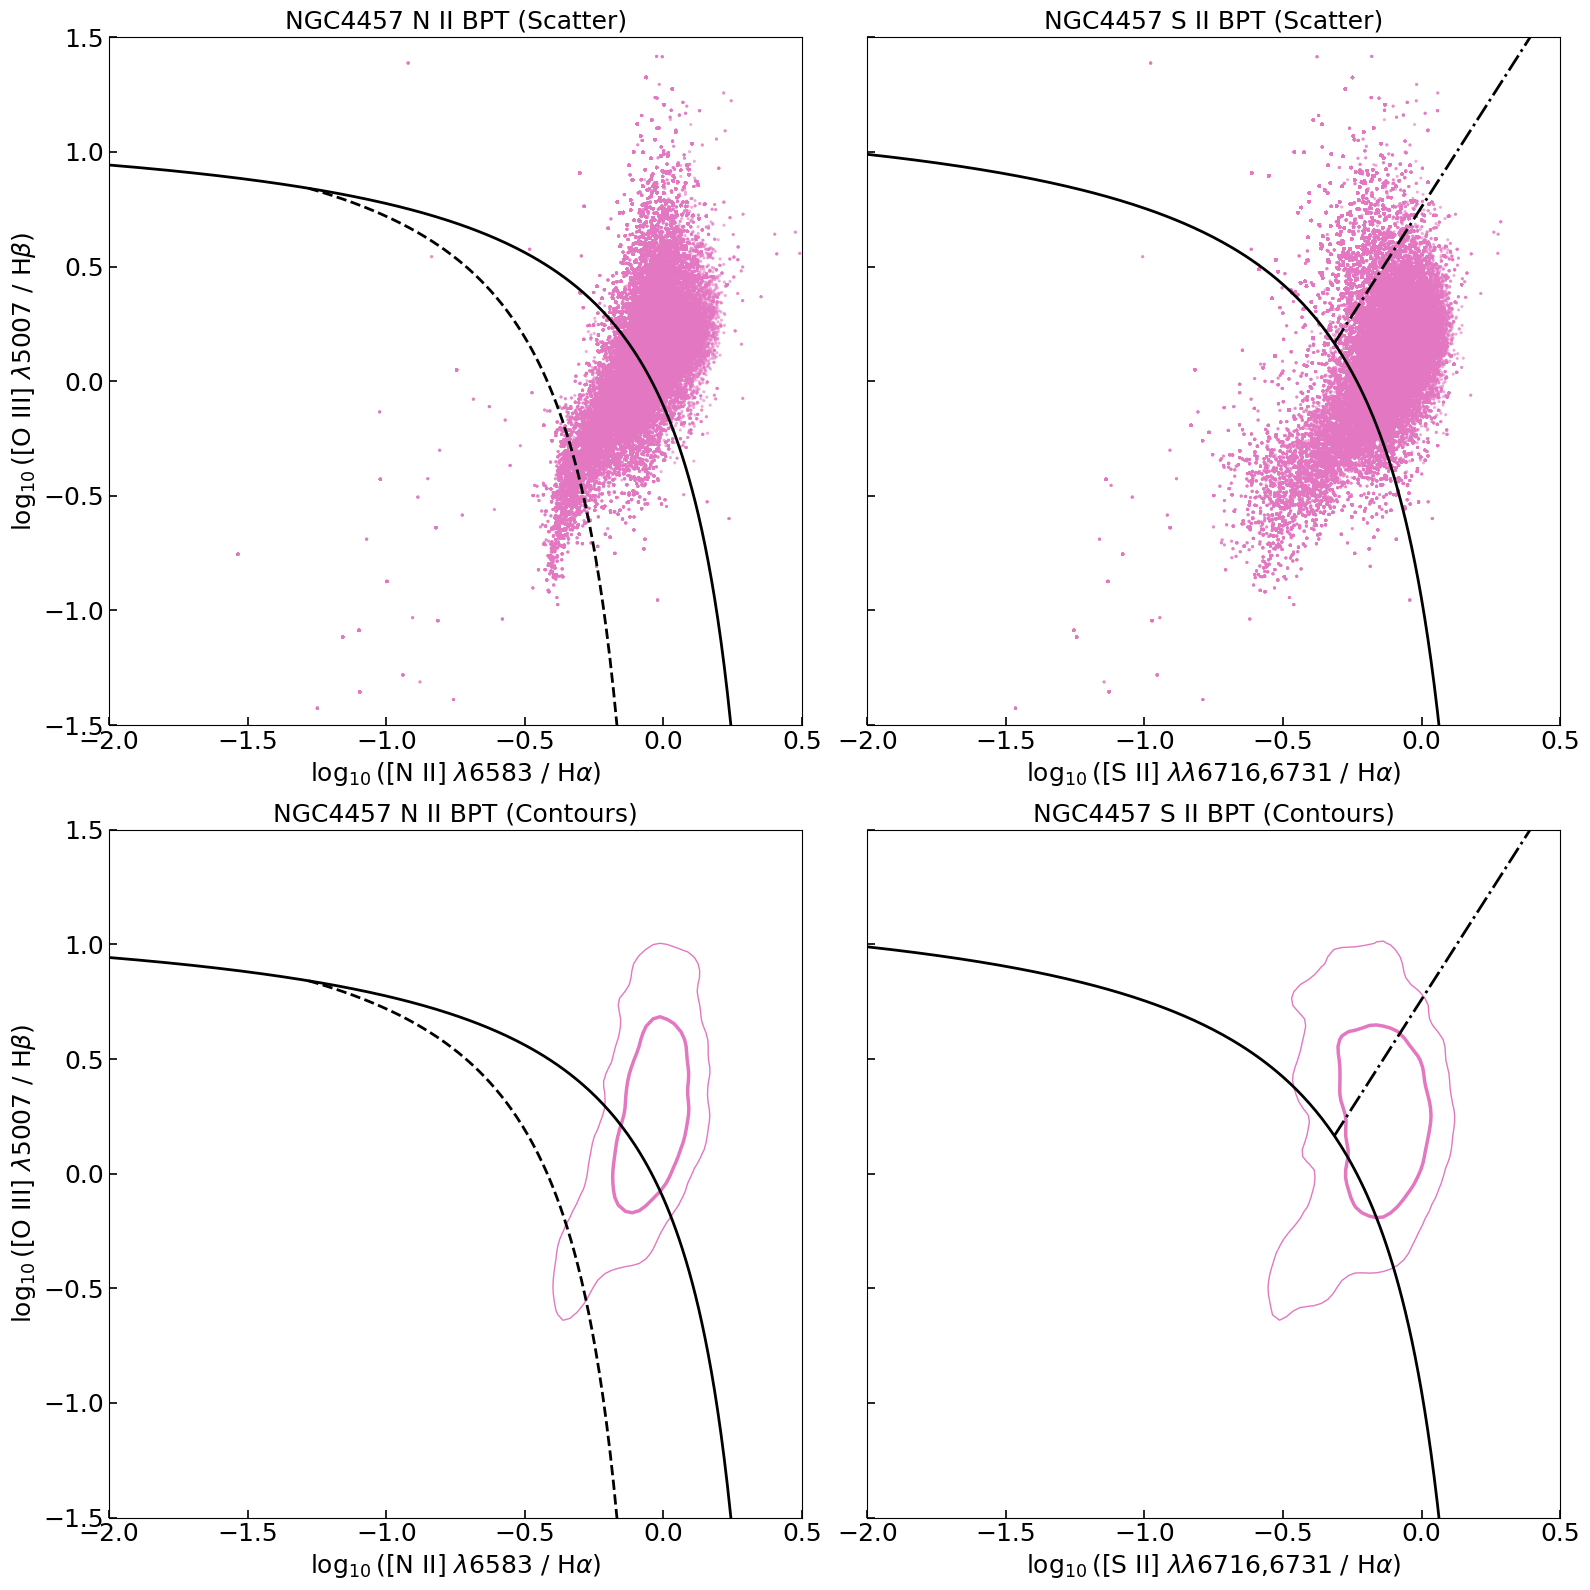

In [12]:
gal = "NGC4457"
i = 9

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

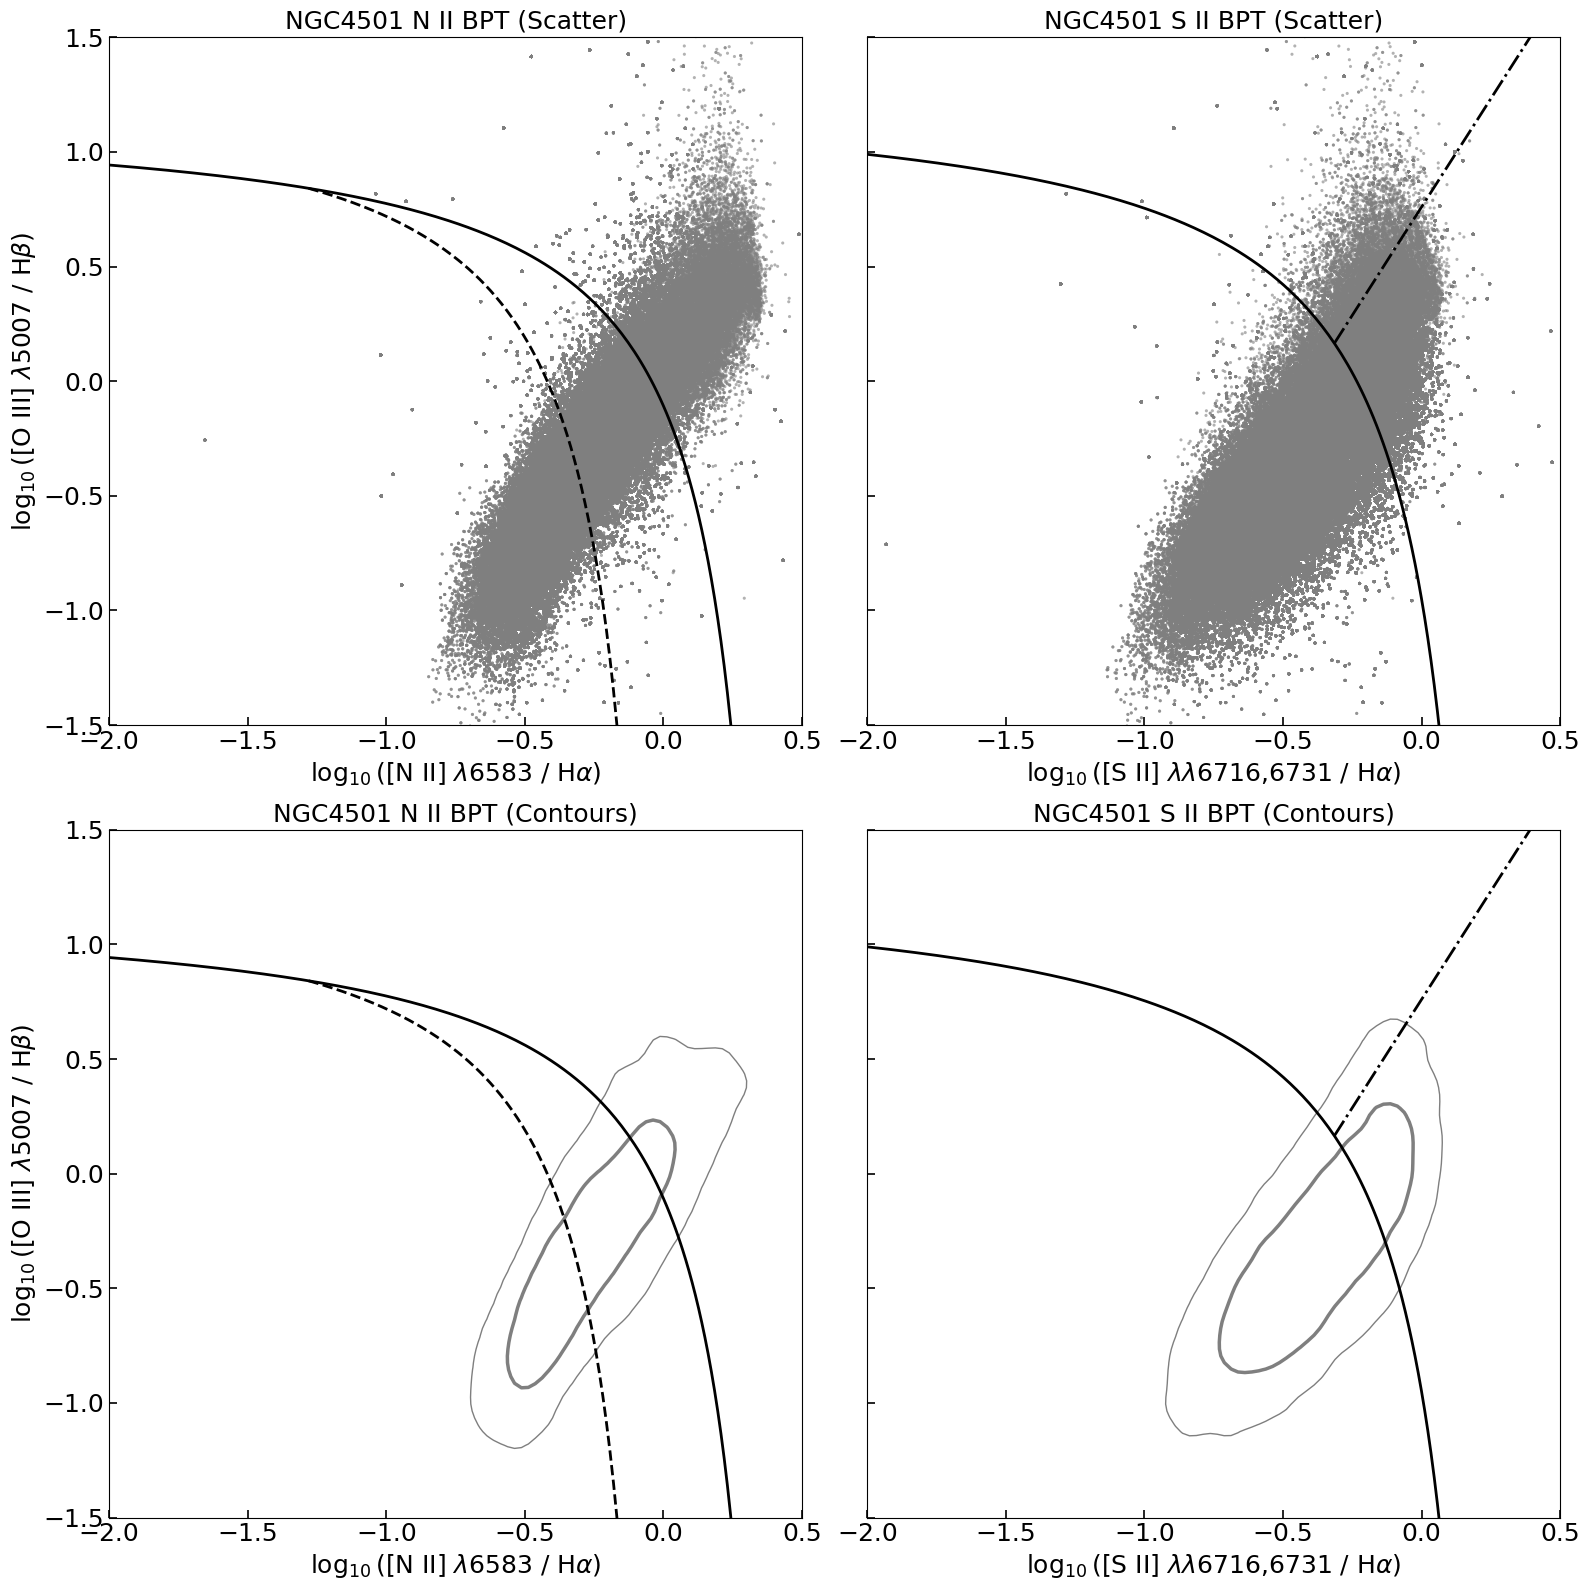

In [13]:
gal = "NGC4501"
i = 10

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

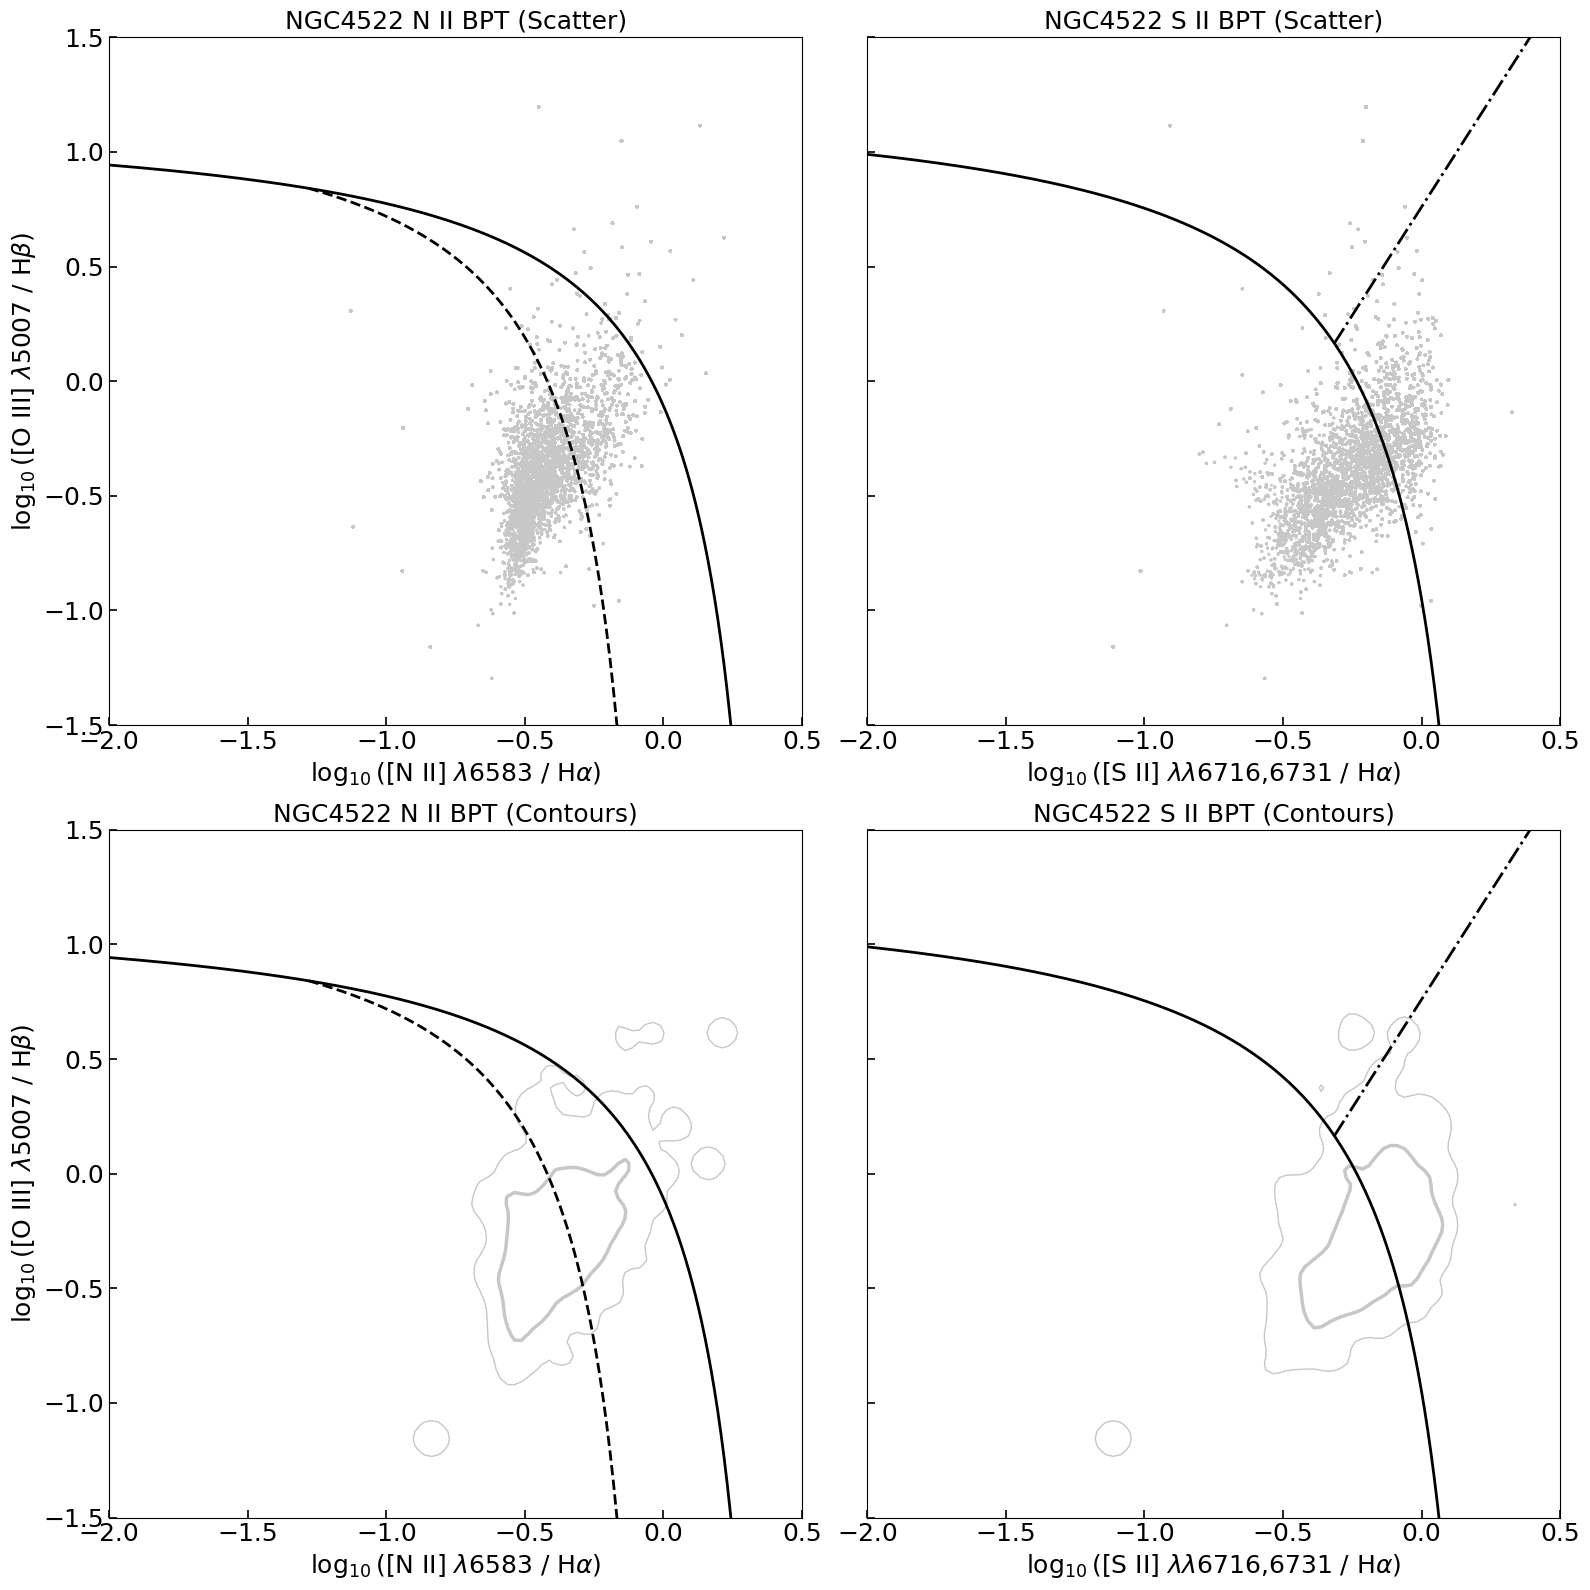

In [14]:
gal = "NGC4522"
i = 11

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

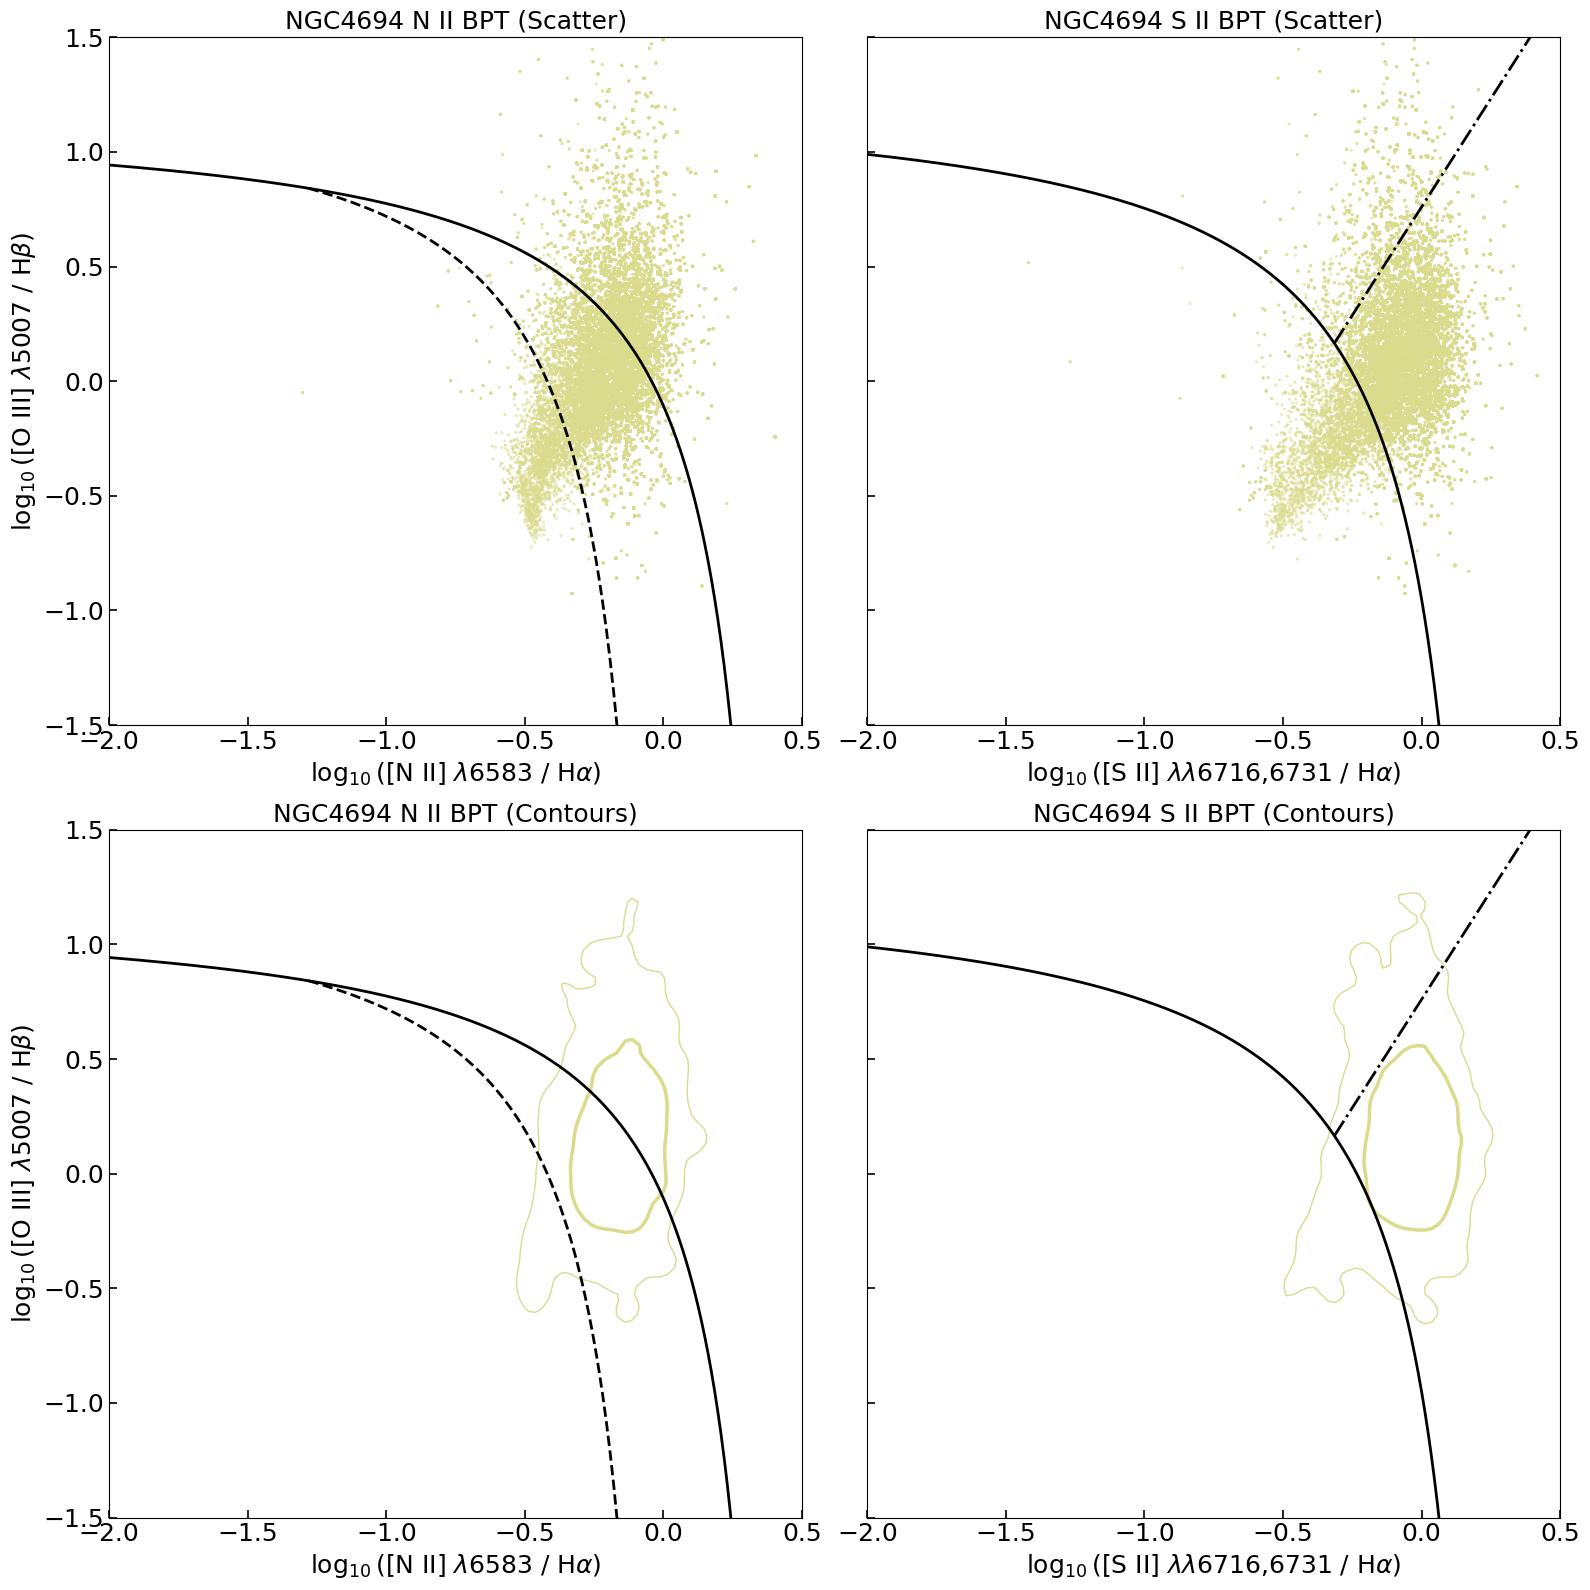

In [15]:
gal = "NGC4694"
i = 12

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()

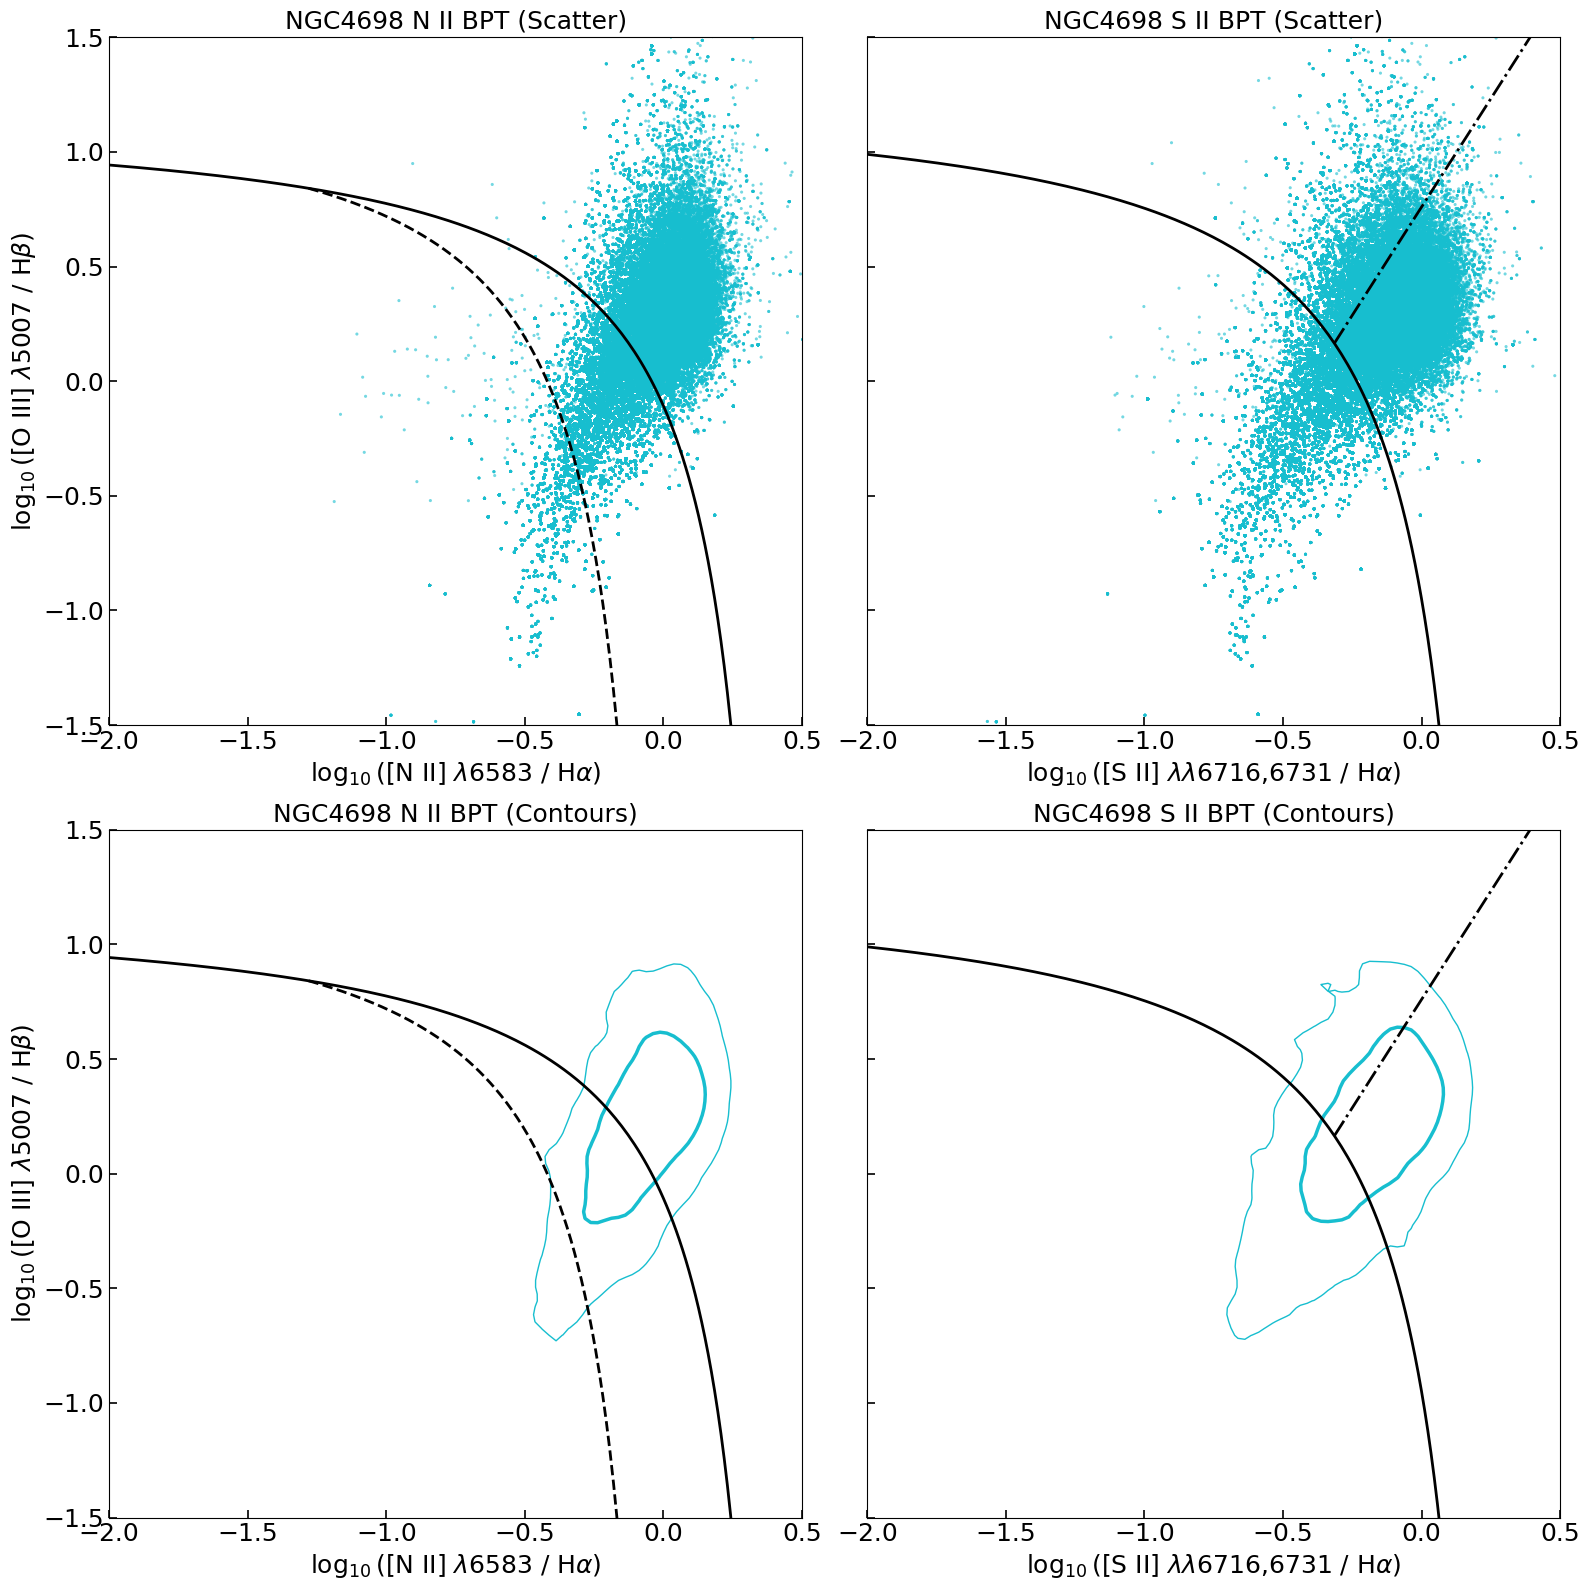

In [16]:
gal = "NGC4698"
i = 13

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharey='row')
mask = (all_gal_idx == i)
x_N2 = all_logN2[mask]
x_S2 = all_logS2[mask]
y_val = all_logO3[mask]
c = colors[i]

# Scatter NII
axes[0,0].scatter(x_N2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[0,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[0,0].set_xlim(-2.0, 0.5)
axes[0,0].set_ylim(-1.5, 1.5)
axes[0,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[0,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[0,0].set_title(f"{gal} N II BPT (Scatter)")

# Scatter SII
axes[0,1].scatter(x_S2, y_val, color=c, s=5, alpha=0.6, edgecolors='none')
axes[0,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[0,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[0,1].set_xlim(-2.0, 0.5)
axes[0,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[0,1].set_title(f"{gal} S II BPT (Scatter)")

# Contour NII
plot_contours(axes[1,0], x_N2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,0].plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'k--', lw=2, label='Kauffmann+03')
axes[1,0].plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'k-', lw=2, label='Kewley+01')
axes[1,0].set_xlim(-2.0, 0.5)
axes[1,0].set_ylim(-1.5, 1.5)
axes[1,0].set_xlabel(r'$\log_{10}$([N II] $\lambda$6583 / H$\alpha$)')
axes[1,0].set_ylabel(r'$\log_{10}$([O III] $\lambda$5007 / H$\beta$)')
axes[1,0].set_title(f"{gal} N II BPT (Contours)")

# Contour SII
plot_contours(axes[1,1], x_S2, y_val, c, label=gal, bins=100, smooth=1.5)
axes[1,1].plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'k-', lw=2, label='Kewley+01')
axes[1,1].plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'k-.', lw=2, label='Seyfert/LINER')
axes[1,1].set_xlim(-2.0, 0.5)
axes[1,1].set_xlabel(r'$\log_{10}$([S II] $\lambda\lambda$6716,6731 / H$\alpha$)')
axes[1,1].set_title(f"{gal} S II BPT (Contours)")

plt.tight_layout()
plt.show()